# Non-Higgs Convergence Testing

This document will include six models of interest to us! We are checking how well they converge as we truncate the hierarchy to see if we identify the same effect as a displacement in the e-fold mapping.

In [1]:
import numpy
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')

import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



Check to make sure files are showing up:

In [6]:
# base_path_root = Path(
#     "/Users/epmeador/Desktop/research/rwarthur/"
#     "inflation_gravitywaves/inflation_code/"
#     "Slow-Roll Parameters Tests/nonhiggs_potential_tests"
# )

# MODEL_ID = "starobinsky"

# for NEQS in [6, 7, 8]:

#     neqs_dir = base_path_root / f"neqs{NEQS}_nonhiggs_{MODEL_ID}"

#     print("\n" + "="*70)
#     print(f"NEQS = {NEQS}")
#     print(f"Looking in: {neqs_dir}")
#     print(f"Exists? {neqs_dir.exists()}")

#     if neqs_dir.exists():
#         subdirs = [p for p in neqs_dir.iterdir() if p.is_dir()]

#         print(f"Number of model folders: {len(subdirs)}")

#         for folder in subdirs:
#             print("  ", folder.name)

# Bases

In [7]:
base_path_root = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/"
    "Slow-Roll Parameters Tests/nonhiggs_potential_tests"
)

MODEL_ID = "starobinsky"

NEQS_LIST = [6, 7, 8]

If I want to pull base files with my naming scheme I use the function below:

In [9]:
def get_model_folder(NEQS, model_id, base_path_root):

    neqs_dir = (
        base_path_root /
        f"neqs{NEQS}_nonhiggs_{model_id}"
    )

    if not neqs_dir.exists():
        raise FileNotFoundError(
            f"Missing NEQS directory:\n{neqs_dir}"
        )

    model_folders = [
        p for p in neqs_dir.iterdir()
        if p.is_dir()
    ]

    if len(model_folders) == 0:
        raise FileNotFoundError(
            f"No model folders found inside:\n{neqs_dir}"
        )

    if len(model_folders) > 1:
        raise RuntimeError(
            f"Found {len(model_folders)} model folders inside:\n"
            f"{neqs_dir}\n"
            "Need to decide which model to use."
        )

    return model_folders[0]


##Build dict

base_dirs = {}

for NEQS in NEQS_LIST:

    folder = get_model_folder(
        NEQS,
        MODEL_ID,
        base_path_root
    )

    base_dirs[NEQS] = folder

    print(f"NEQS={NEQS}:")
    print(f"  {folder}")

NEQS=6:
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs6_nonhiggs_starobinsky/lam2_2.7701900000e-04_lam3_-1.1798429568e-05_lam4_0.0000000000e+00_lam5_0.0000000000e+00
NEQS=7:
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs7_nonhiggs_starobinsky/lam2_2.7701900000e-04_lam3_-1.1798429568e-05_lam4_-4.6184500000e-08_lam5_0.0000000000e+00
NEQS=8:
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs8_nonhiggs_starobinsky/lam2_2.7701900000e-04_lam3_-1.1798429568e-05_lam4_-4.6184500000e-08_lam5_1.4171600000e-09


For path:

In [10]:
def load_path_data(NEQS):

    folder = base_dirs[NEQS]

    matches = list(
        folder.glob(
            f"path_neqs{NEQS}_N0to70_paramsAtN60_*.dat"
        )
    )

    if len(matches) == 0:
        raise FileNotFoundError(
            f"No path file found in:\n{folder}"
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"Multiple path files found in:\n{folder}"
        )

    file_path = matches[0]

    data = pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None
    ).values

    return data

For spectra:

In [11]:
def load_specs(NEQS):

    folder = base_dirs[NEQS]

    s = np.loadtxt(
        folder / f"spec_s_neqs{NEQS}.dat"
    )

    t = np.loadtxt(
        folder / f"spec_t_neqs{NEQS}.dat"
    )

    k_s = s[:, 0]
    Ps = np.abs(s[:, 1])

    k_t = t[:, 0]
    Pt = np.abs(t[:, 1])

    return k_s, Ps, k_t, Pt

Helper functions and color:

In [12]:
SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}

colors = {
    5: "mediumseagreen",
    6: "lightskyblue",
    7: "paleturquoise",
    8: "thistle",
    9: "pink",
}


def prepare_increasing(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    return x[order], y[order]


def normalize_curve_at_Nref(N, Y, N_ref=60.0, ref_floor=1e-20):
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range [{N_use.min()}, {N_use.max()}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(f"Reference too small: {Y_ref:.3e}")

    return N_use, Y_use / Y_ref, Y_ref


def normalize_at_ref(k, P, k_ref):
    k, P = prepare_increasing(k, P)

    if not (k.min() <= k_ref <= k.max()):
        raise ValueError(
            f"k_ref={k_ref} outside range [{k.min()}, {k.max()}]"
        )

    P_ref = np.interp(k_ref, k, P)

    return k, P / P_ref, P_ref


def fractional_difference_on_overlap(
    x, y, x_ref, y_ref, frac_floor=1e-30
):
    x, y = prepare_increasing(x, y)
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)

    xmin = max(np.min(x), np.min(x_ref))
    xmax = min(np.max(x), np.max(x_ref))

    mask = (x >= xmin) & (x <= xmax)

    x_use = x[mask]
    y_use = y[mask]

    y_ref_interp = np.interp(x_use, x_ref, y_ref)

    frac = (y_use - y_ref_interp) / np.where(
        np.abs(y_ref_interp) > frac_floor,
        y_ref_interp,
        np.nan,
    )

    return x_use, frac

# Plot Background Variables:

## BEFORE SHIFTING

In [13]:
def plot_HV_shape_only_with_frac_error_limitedN(
    base_path_root,
    save_name=None,
    suptitle=None,
    N_ref=60.0,
    ref_floor=1e-20,
    frac_floor=1e-30,
    N_min=20.0,
    N_max=60.0,
):

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    # -------------------------------------------------
    # Truncation orders we currently have
    # -------------------------------------------------
    NEQS_LIST = [6, 7, 8]

    # -------------------------------------------------
    # Restrict plots to desired N window
    # -------------------------------------------------
    def apply_N_window(N, Y):
        mask = (N >= N_min) & (N <= N_max)
        return N[mask], Y[mask]

    # -------------------------------------------------
    # Load and normalize each model
    # -------------------------------------------------
    model_data = {}

    for NEQS in NEQS_LIST:

        param_name, param_label = SCAN_INFO[NEQS]

        # Uses the new generic loader
        data = load_path_data(NEQS)

        # save_path writes:
        # y[0], ..., y[NEQS-1], N, V, KE
        N = data[:, NEQS]
        H = data[:, 1]
        V = data[:, NEQS + 1]

        # Normalize H at N_ref
        N_H, H_norm, Hstar = normalize_curve_at_Nref(
            N,
            H,
            N_ref=N_ref,
            ref_floor=ref_floor,
        )

        # Normalize V at N_ref
        N_V, V_norm, Vstar = normalize_curve_at_Nref(
            N,
            V,
            N_ref=N_ref,
            ref_floor=ref_floor,
        )

        # Apply plotting window
        N_H, H_norm = apply_N_window(N_H, H_norm)
        N_V, V_norm = apply_N_window(N_V, V_norm)

        model_data[NEQS] = {
            "N_H": N_H,
            "H_norm": H_norm,
            "H_ref": Hstar,

            "N_V": N_V,
            "V_norm": V_norm,
            "V_ref": Vstar,

            "param_name": param_name,
            "param_label": param_label,
        }

    # -------------------------------------------------
    # Use NEQs=6 truncation as reference
    # -------------------------------------------------
    REF_NEQS = 6
    ref_curve = model_data[REF_NEQS]

    # -------------------------------------------------
    # Create figure
    # -------------------------------------------------
    fig, axs = plt.subplots(
        2,
        2,
        figsize=(18, 10),
        constrained_layout=True,
    )

    ax_H, ax_V = axs[0]
    ax_dH, ax_dV = axs[1]

    # -------------------------------------------------
    # Top row: normalized H and V
    # -------------------------------------------------
    for NEQS in NEQS_LIST:

        d = model_data[NEQS]

        label = rf"NEQS={NEQS}"

        ax_H.plot(
            d["N_H"],
            d["H_norm"],
            lw=2.4,
            color=colors[NEQS],
            label=label,
        )

        ax_V.plot(
            d["N_V"],
            d["V_norm"],
            lw=2.4,
            color=colors[NEQS],
            label=label,
        )

    ax_H.set_title(
        rf"Shape-only Hubble evolution: $H/H(N={N_ref})$"
    )

    ax_V.set_title(
        rf"Shape-only potential evolution: $V/V(N={N_ref})$"
    )

    ax_H.set_ylabel(
        rf"$H/H(N={N_ref})$"
    )

    ax_V.set_ylabel(
        rf"$V/V(N={N_ref})$"
    )

    # -------------------------------------------------
    # Bottom row: fractional differences
    # relative to highest-order model
    # -------------------------------------------------
    for NEQS in NEQS_LIST:

        d = model_data[NEQS]

        N_use_H, frac_H = fractional_difference_on_overlap(
            d["N_H"],
            d["H_norm"],
            ref_curve["N_H"],
            ref_curve["H_norm"],
            frac_floor=frac_floor,
        )

        N_use_V, frac_V = fractional_difference_on_overlap(
            d["N_V"],
            d["V_norm"],
            ref_curve["N_V"],
            ref_curve["V_norm"],
            frac_floor=frac_floor,
        )

        ax_dH.plot(
            N_use_H,
            100.0 * frac_H,
            lw=2.2,
            color=colors[NEQS],
            label=rf"NEQS={NEQS}",
        )

        ax_dV.plot(
            N_use_V,
            100.0 * frac_V,
            lw=2.2,
            color=colors[NEQS],
            label=rf"NEQS={NEQS}",
        )

    ax_dH.axhline(
        0.0,
        color="black",
        linestyle="--",
        lw=1.1,
        alpha=0.65,
    )

    ax_dV.axhline(
        0.0,
        color="black",
        linestyle="--",
        lw=1.1,
        alpha=0.65,
    )

    ax_dH.set_title(
        rf"Fractional difference in $H(N)$ relative to NEQS={REF_NEQS}"
    )

    ax_dV.set_title(
        rf"Fractional difference in $V(N)$ relative to NEQS={REF_NEQS}"
    )

    ax_dH.set_xlabel(r"$N$")
    ax_dV.set_xlabel(r"$N$")

    ax_dH.set_ylabel(
        rf"$100\times\Delta H/H_{{\rm NEQS={REF_NEQS}}}$"
    )

    ax_dV.set_ylabel(
        rf"$100\times\Delta V/V_{{\rm NEQS={REF_NEQS}}}$"
    )

    # -------------------------------------------------
    # Styling
    # -------------------------------------------------
    for ax in axs.ravel():

        ax.invert_xaxis()

        ax.grid(
            True,
            which="major",
            alpha=0.25,
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12,
        )

        ax.minorticks_on()

        handles, labels = ax.get_legend_handles_labels()

        if len(handles) > 0:
            ax.legend(
                frameon=False,
                fontsize=11,
            )

    # -------------------------------------------------
    # Overall title
    # -------------------------------------------------
    if suptitle is None:
        suptitle = (
            rf"{MODEL_ID.capitalize()} background convergence "
            rf"over ${N_min}<N<{N_max}$"
        )

    fig.suptitle(
        suptitle,
        fontsize=22,
    )

    # -------------------------------------------------
    # Optional save
    # -------------------------------------------------
    if save_name is not None:
        fig.savefig(
            save_name,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

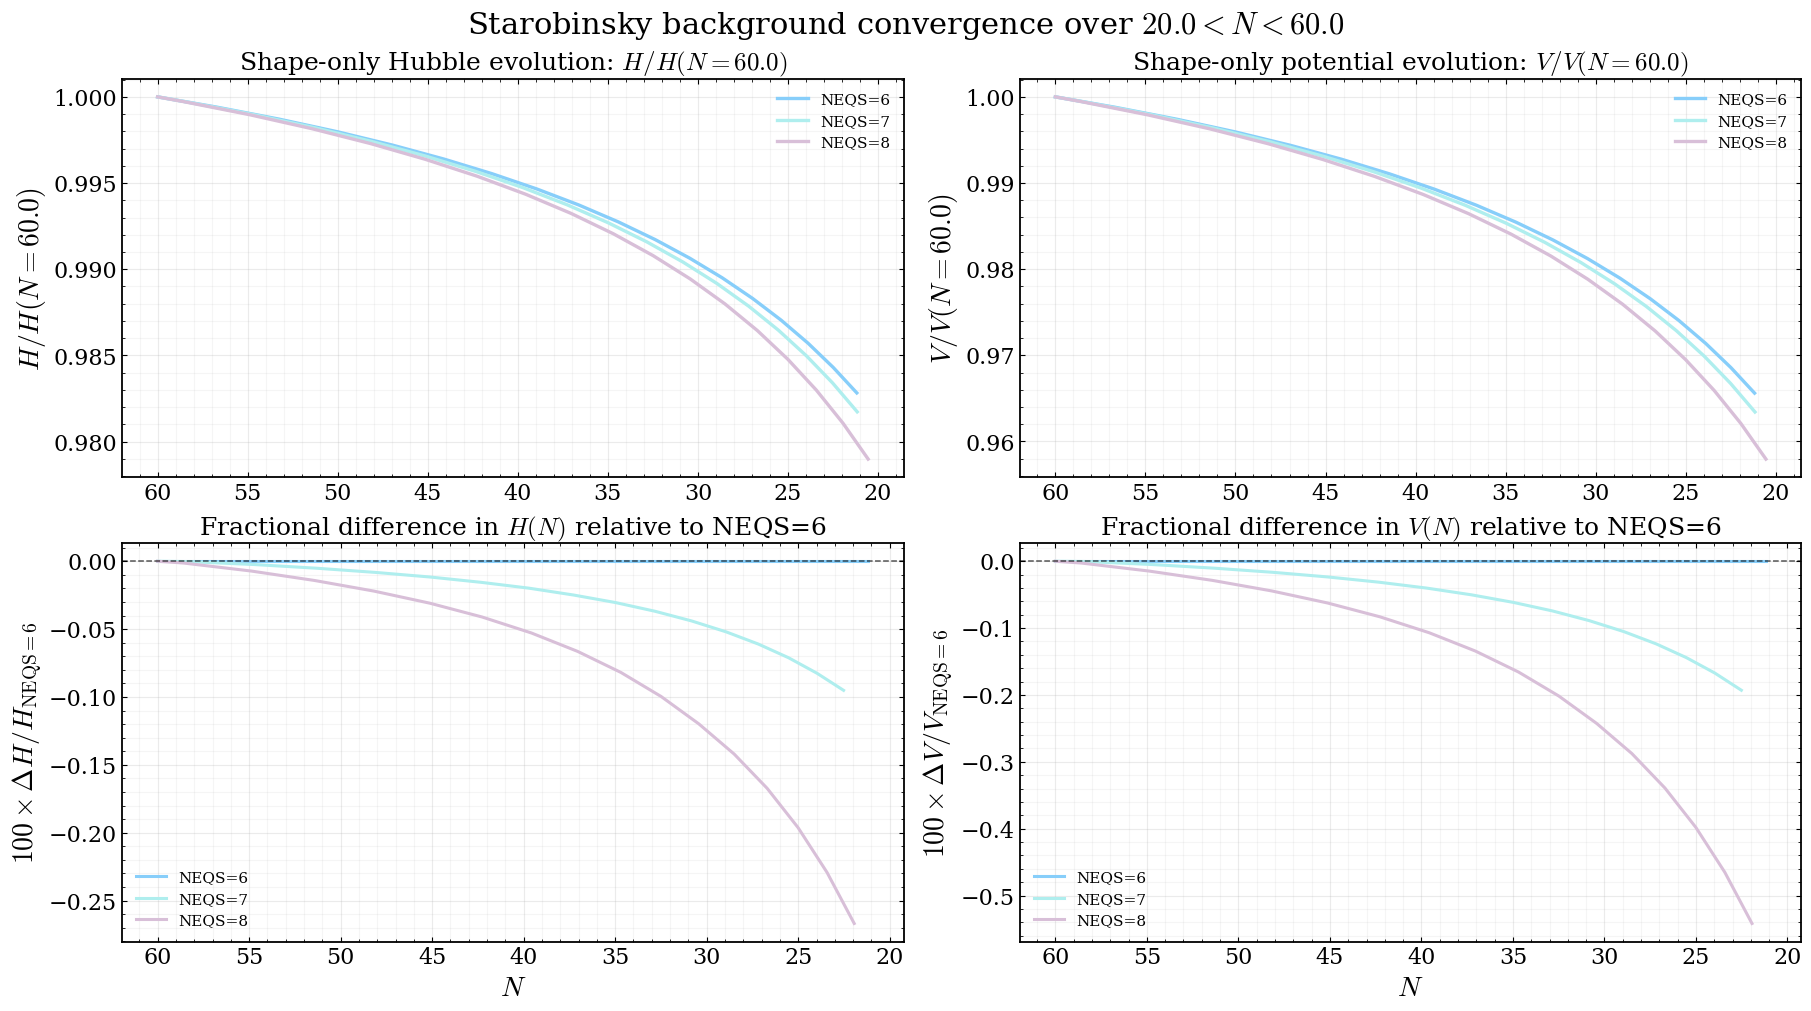

In [14]:
plot_HV_shape_only_with_frac_error_limitedN(
    base_path_root=base_path_root,
    N_ref=60.0,
    N_min=20.0,
    N_max=60.0,
)

#If I wanna save it would do, save_name
# plot_HV_shape_only_with_frac_error_limitedN(
#     base_path_root=base_path_root,
#     N_ref=60.0,
#     N_min=20.0,
#     N_max=60.0,
#     save_name=os.path.join(
#         base_path_root,
#         f"{MODEL_ID}_HV_convergence_neqs6_ref.png"
#     ),
# )

In [15]:
def plot_base_spectra_overlay_with_frac_errors(
    base_path_root,
    ref_NEQS=6,
    k_ref=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    normalize=True,
    tolerance=5.0,
    save_name=None,
    show=True,
):

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    NEQS_LIST = [6, 7, 8]

    def normalize_at_ref(k, P):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range "
                f"[{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(
                f"Reference spectrum too small at k={k_ref}"
            )

        return k, P / P_ref, P_ref


    def frac_on_ref_grid(
        k_ref_grid,
        P_ref,
        k_cmp,
        P_cmp,
        kmin=None,
        kmax=None,
    ):

        k_ref_grid, P_ref = prepare_increasing(
            k_ref_grid,
            P_ref
        )

        k_cmp, P_cmp = prepare_increasing(
            k_cmp,
            P_cmp
        )

        xmin = max(
            k_ref_grid.min(),
            k_cmp.min()
        )

        xmax = min(
            k_ref_grid.max(),
            k_cmp.max()
        )

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (
            (k_ref_grid >= xmin)
            & (k_ref_grid <= xmax)
        )

        k_use = k_ref_grid[mask]
        P_ref_use = P_ref[mask]

        if len(k_use) == 0:
            raise ValueError(
                "No overlapping k range for fractional error."
            )

        P_cmp_interp = np.interp(
            k_use,
            k_cmp,
            P_cmp
        )

        frac = (
            P_cmp_interp - P_ref_use
        ) / P_ref_use

        return k_use, frac


    # -------------------------------------------------
    # Load reference model
    # -------------------------------------------------
    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
        ref_NEQS
    )

    if normalize:

        k_s_ref, Ps_ref, _ = normalize_at_ref(
            k_s_ref_raw,
            Ps_ref_raw
        )

        k_t_ref, Pt_ref, _ = normalize_at_ref(
            k_t_ref_raw,
            Pt_ref_raw
        )

        ylab_s = rf"$P_s/P_s(k={k_ref})$"
        ylab_t = rf"$P_t/P_t(k={k_ref})$"

    else:

        k_s_ref, Ps_ref = prepare_increasing(
            k_s_ref_raw,
            Ps_ref_raw
        )

        k_t_ref, Pt_ref = prepare_increasing(
            k_t_ref_raw,
            Pt_ref_raw
        )

        ylab_s = r"$P_s(k)$"
        ylab_t = r"$P_t(k)$"


    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_s, ax_t = axes[0]
    ax_s_err, ax_t_err = axes[1]

    rows = []


    # -------------------------------------------------
    # Loop over truncation order
    # -------------------------------------------------
    for NEQS in NEQS_LIST:

        param_name, param_label = SCAN_INFO[NEQS]

        k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
            NEQS
        )

        if normalize:

            k_s, Ps_plot, _ = normalize_at_ref(
                k_s_raw,
                Ps_raw
            )

            k_t, Pt_plot, _ = normalize_at_ref(
                k_t_raw,
                Pt_raw
            )

        else:

            k_s, Ps_plot = prepare_increasing(
                k_s_raw,
                Ps_raw
            )

            k_t, Pt_plot = prepare_increasing(
                k_t_raw,
                Pt_raw
            )

        color = colors.get(NEQS, None)

        label = rf"NEQS={NEQS}"


        # -------------------------------------------------
        # Scalar plotting range
        # -------------------------------------------------
        scalar_mask = np.ones_like(
            k_s,
            dtype=bool
        )

        if k_min_scalar is not None:
            scalar_mask &= k_s >= k_min_scalar

        if k_max_scalar is not None:
            scalar_mask &= k_s <= k_max_scalar


        # -------------------------------------------------
        # Spectra
        # -------------------------------------------------
        ax_s.loglog(
            k_s[scalar_mask],
            Ps_plot[scalar_mask],
            color=color,
            lw=2.3,
            label=label,
        )

        ax_t.loglog(
            k_t,
            Pt_plot,
            color=color,
            lw=2.3,
            label=label,
        )


        # -------------------------------------------------
        # Fractional differences relative to reference
        # -------------------------------------------------
        k_s_err, frac_s = frac_on_ref_grid(
            k_s_ref,
            Ps_ref,
            k_s,
            Ps_plot,
            kmin=k_min_scalar,
            kmax=k_max_scalar,
        )

        k_t_err, frac_t = frac_on_ref_grid(
            k_t_ref,
            Pt_ref,
            k_t,
            Pt_plot,
            kmin=None,
            kmax=None,
        )


        ax_s_err.semilogx(
            k_s_err,
            100.0 * frac_s,
            color=color,
            lw=2.0,
            label=rf"NEQS={NEQS}",
        )

        ax_t_err.semilogx(
            k_t_err,
            100.0 * frac_t,
            color=color,
            lw=2.0,
            label=rf"NEQS={NEQS}",
        )


        # -------------------------------------------------
        # Convergence summary
        # -------------------------------------------------
        rows.append({
            "NEQS": NEQS,
            "param_name": param_name,
            "mean_abs_dPs_pct":
                100.0 * np.nanmean(np.abs(frac_s)),
            "max_abs_dPs_pct":
                100.0 * np.nanmax(np.abs(frac_s)),
            "mean_abs_dPt_pct":
                100.0 * np.nanmean(np.abs(frac_t)),
            "max_abs_dPt_pct":
                100.0 * np.nanmax(np.abs(frac_t)),
        })


    # -------------------------------------------------
    # Reference lines
    # -------------------------------------------------
    ax_s.axvline(
        k_ref,
        color="black",
        ls=":",
        lw=1.2,
        alpha=0.7,
    )

    ax_t.axvline(
        k_ref,
        color="black",
        ls=":",
        lw=1.2,
        alpha=0.7,
    )

    for ax in [ax_s_err, ax_t_err]:

        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.7,
        )

        ax.axhline(
            tolerance,
            color="black",
            ls=":",
            lw=1.4,
            alpha=0.8,
            label=rf"${tolerance:.0f}\%$ tolerance",
        )

        ax.axhline(
            -tolerance,
            color="black",
            ls=":",
            lw=1.4,
            alpha=0.8,
        )


    # -------------------------------------------------
    # Titles and labels
    # -------------------------------------------------
    ax_s.set_title(
        rf"{MODEL_ID.capitalize()} scalar spectra"
    )

    ax_t.set_title(
        rf"{MODEL_ID.capitalize()} tensor spectra"
    )

    ax_s_err.set_title(
        rf"Scalar fractional difference relative to NEQS={ref_NEQS}"
    )

    ax_t_err.set_title(
        rf"Tensor fractional difference relative to NEQS={ref_NEQS}"
    )

    ax_s.set_xlabel(r"$k$")
    ax_t.set_xlabel(r"$k$")
    ax_s_err.set_xlabel(r"$k$")
    ax_t_err.set_xlabel(r"$k$")

    ax_s.set_ylabel(ylab_s)
    ax_t.set_ylabel(ylab_t)

    ax_s_err.set_ylabel(
        rf"$100\times\Delta P_s/P_{{s,\rm NEQS={ref_NEQS}}}$"
    )

    ax_t_err.set_ylabel(
        rf"$100\times\Delta P_t/P_{{t,\rm NEQS={ref_NEQS}}}$"
    )


    # -------------------------------------------------
    # Scalar k range
    # -------------------------------------------------
    ax_s.set_xlim(
        k_min_scalar,
        k_max_scalar
    )

    ax_s_err.set_xlim(
        k_min_scalar,
        k_max_scalar
    )


    # -------------------------------------------------
    # Styling
    # -------------------------------------------------
    for ax in axes.ravel():

        ax.grid(
            True,
            which="major",
            alpha=0.25
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12
        )

        ax.minorticks_on()
        ax.legend(
            frameon=False,
            fontsize=11
        )


    fig.suptitle(
        rf"{MODEL_ID.capitalize()} spectra convergence "
        rf"relative to NEQS={ref_NEQS}",
        fontsize=22,
    )


    # -------------------------------------------------
    # Optional save
    # -------------------------------------------------
    if save_name is not None:

        fig.savefig(
            save_name,
            dpi=300,
            bbox_inches="tight",
        )


    if show:
        plt.show()
    else:
        plt.close(fig)


    # -------------------------------------------------
    # Summary table
    # -------------------------------------------------
    summary_df = pd.DataFrame(rows)

    print("\n=== Base spectra convergence summary ===")
    print(summary_df.to_string(index=False))

    return summary_df

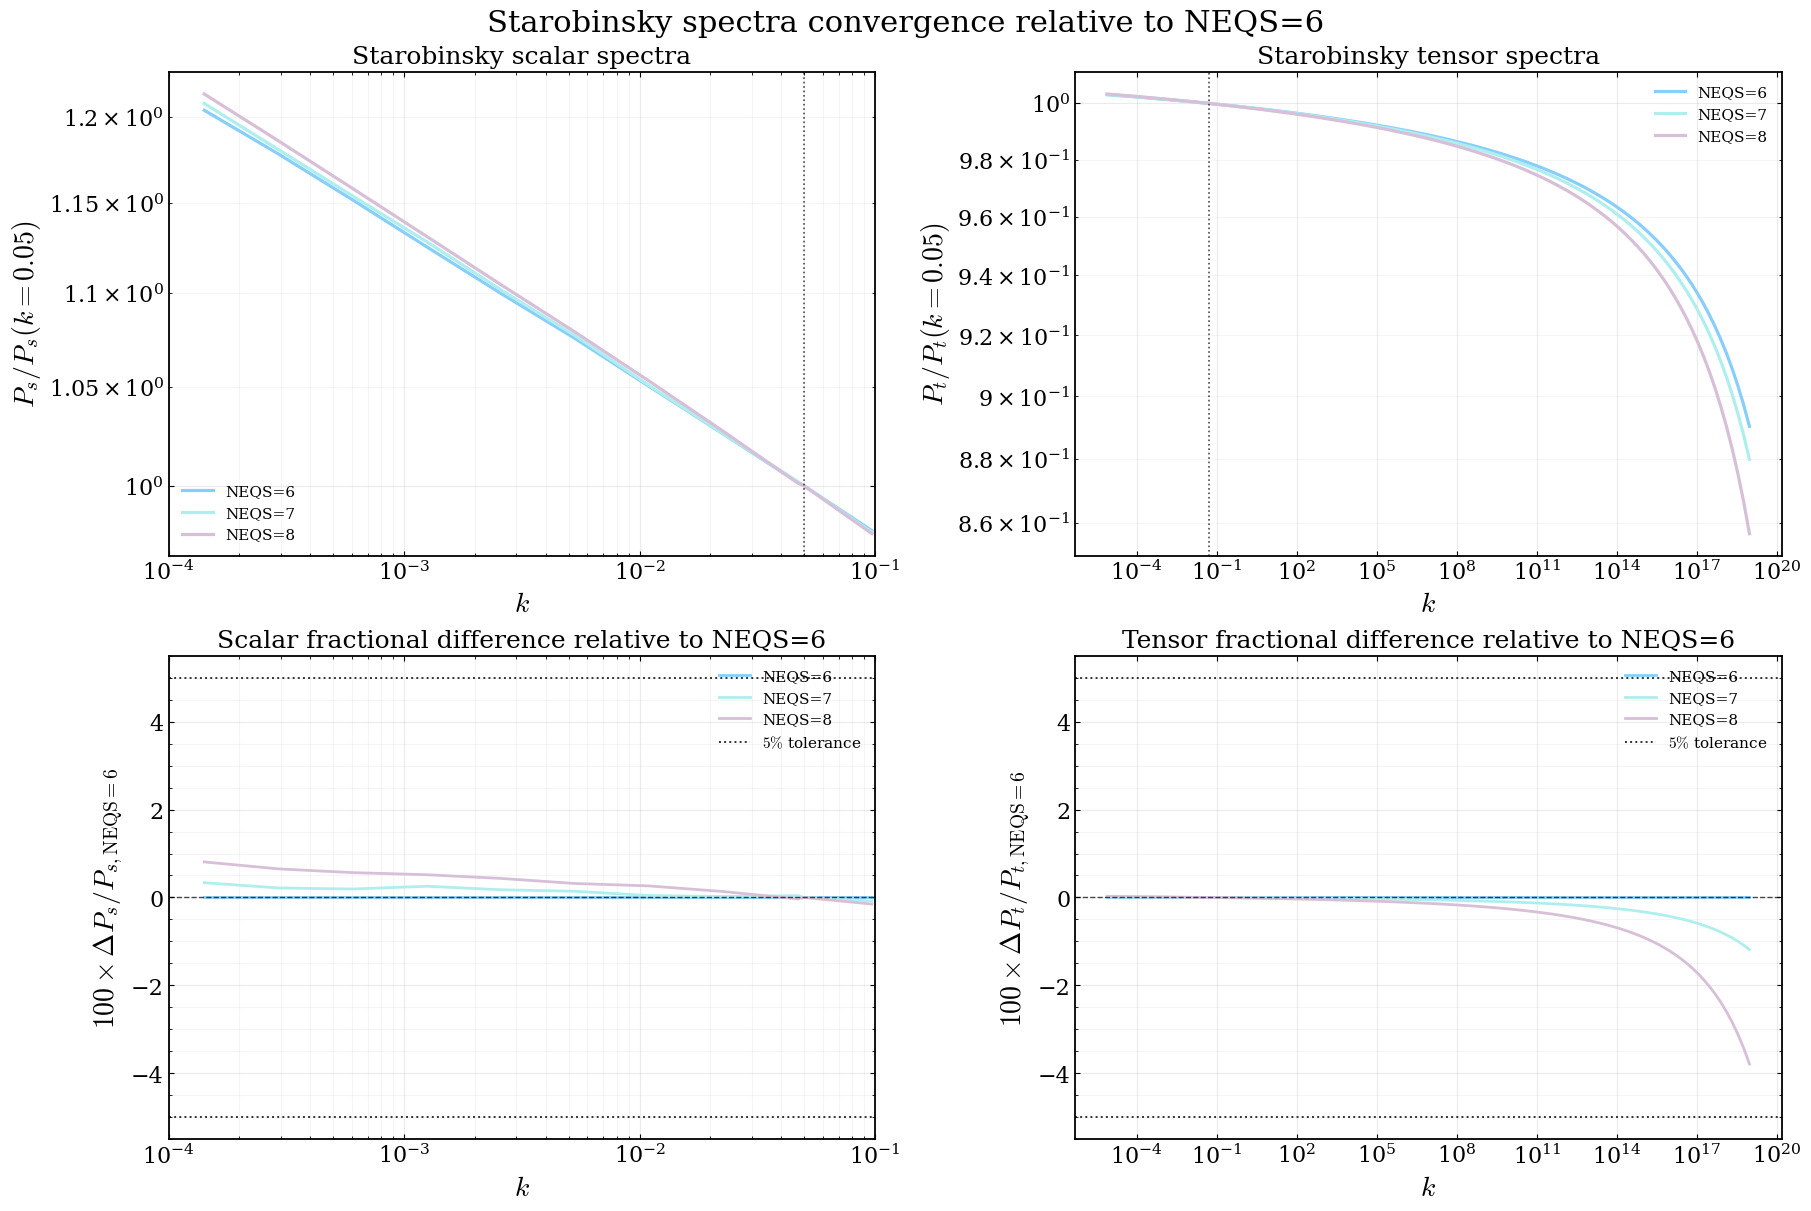


=== Base spectra convergence summary ===
 NEQS param_name  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    6       lam3          0.000000         0.000000          0.000000         0.000000
    7       lam4          0.136684         0.335940          0.178370         1.184483
    8       lam5          0.352152         0.808554          0.507139         3.786303


In [16]:
base_spectra_summary_df = plot_base_spectra_overlay_with_frac_errors(
    base_path_root=base_path_root,
    ref_NEQS=6,
    k_ref=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    tolerance=5.0,
    save_name=None,
)

# base_spectra_summary_df = plot_base_spectra_overlay_with_frac_errors(
#     base_path_root=base_path_root,
#     ref_NEQS=6,
#     k_ref=0.05,
#     k_min_scalar=1e-4,
#     k_max_scalar=1e-1,
#     tolerance=5.0,
#     save_name=f"{MODEL_ID}_spectra_convergence_relative_to_neqs6.pdf",
# )

In [18]:
def plot_base_spectra_derivative_convergence(
    base_path_root,
    ref_NEQS=6,
    k_min_plot_s=1e-4,
    k_max_plot_s=1e-1,
    k_min_plot_t=None,
    k_max_plot_t=None,
    smoothing=0.0,
    tolerance=5.0,
    save_name=None,
    show=True,
):

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,

        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    # -------------------------------------------------
    # Truncation orders currently available
    # -------------------------------------------------
    NEQS_LIST = [6, 7, 8]

    if ref_NEQS not in NEQS_LIST:
        raise ValueError(
            f"ref_NEQS={ref_NEQS} not in available NEQS_LIST={NEQS_LIST}"
        )

    # -------------------------------------------------
    # Construct d ln(P) / d ln(k)
    # -------------------------------------------------
    def prepare_log_spline(k, P, smoothing=0.0):

        k = np.asarray(k)
        P = np.asarray(P)

        mask = (
            (k > 0)
            & (P > 0)
            & np.isfinite(k)
            & np.isfinite(P)
        )

        k = k[mask]
        P = P[mask]

        order = np.argsort(k)
        k = k[order]
        P = P[order]

        x = np.log(k)
        y = np.log(P)

        # Remove duplicate x values if they exist
        x_unique = np.unique(x)

        y_unique = np.array([
            np.mean(y[x == xu])
            for xu in x_unique
        ])

        if len(x_unique) < 4:
            raise ValueError(
                "Need at least 4 unique k values for cubic spline."
            )

        spl = UnivariateSpline(
            x_unique,
            y_unique,
            s=smoothing,
            k=3,
        )

        # d ln(P) / d ln(k)
        d1 = spl.derivative(1)(x_unique)

        return np.exp(x_unique), d1

    # -------------------------------------------------
    # Restrict data to requested k window
    # -------------------------------------------------
    def apply_k_window(k, y, kmin=None, kmax=None):

        mask = np.ones_like(
            k,
            dtype=bool,
        )

        if kmin is not None:
            mask &= k >= kmin

        if kmax is not None:
            mask &= k <= kmax

        return k[mask], y[mask]

    # -------------------------------------------------
    # Fractional difference on reference k-grid
    # -------------------------------------------------
    def frac_on_ref_grid(
        k_ref,
        y_ref,
        k_cmp,
        y_cmp,
        floor=1e-30,
    ):

        k_ref, y_ref = prepare_increasing(
            k_ref,
            y_ref
        )

        k_cmp, y_cmp = prepare_increasing(
            k_cmp,
            y_cmp
        )

        xmin = max(
            k_ref.min(),
            k_cmp.min()
        )

        xmax = min(
            k_ref.max(),
            k_cmp.max()
        )

        mask = (
            (k_ref >= xmin)
            & (k_ref <= xmax)
        )

        k_use = k_ref[mask]
        y_ref_use = y_ref[mask]

        if len(k_use) == 0:
            raise ValueError(
                "No overlapping k range for derivative comparison."
            )

        y_cmp_interp = np.interp(
            k_use,
            k_cmp,
            y_cmp
        )

        frac = (
            y_cmp_interp - y_ref_use
        ) / np.where(
            np.abs(y_ref_use) > floor,
            y_ref_use,
            np.nan,
        )

        return k_use, frac

    # -------------------------------------------------
    # Reference derivatives
    # -------------------------------------------------
    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
        ref_NEQS
    )

    k_s_ref, dlnPs_ref = prepare_log_spline(
        k_s_ref_raw,
        Ps_ref_raw,
        smoothing=smoothing,
    )

    k_t_ref, dlnPt_ref = prepare_log_spline(
        k_t_ref_raw,
        Pt_ref_raw,
        smoothing=smoothing,
    )

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_dPs, ax_dPt = axes[0]
    ax_errPs, ax_errPt = axes[1]

    rows = []

    # -------------------------------------------------
    # Loop over truncation order
    # -------------------------------------------------
    for NEQS in NEQS_LIST:

        param_name, param_label = SCAN_INFO[NEQS]

        k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
            NEQS
        )

        # Scalar derivative
        k_s, dlnPs = prepare_log_spline(
            k_s_raw,
            Ps_raw,
            smoothing=smoothing,
        )

        # Tensor derivative
        k_t, dlnPt = prepare_log_spline(
            k_t_raw,
            Pt_raw,
            smoothing=smoothing,
        )

        color = colors.get(
            NEQS,
            None
        )

        label = rf"NEQS={NEQS}"

        # -------------------------------------------------
        # Apply plotting windows
        # -------------------------------------------------
        k_s_plot, dlnPs_plot = apply_k_window(
            k_s,
            dlnPs,
            kmin=k_min_plot_s,
            kmax=k_max_plot_s,
        )

        k_t_plot, dlnPt_plot = apply_k_window(
            k_t,
            dlnPt,
            kmin=k_min_plot_t,
            kmax=k_max_plot_t,
        )

        # -------------------------------------------------
        # Plot spectral derivatives
        # -------------------------------------------------
        ax_dPs.semilogx(
            k_s_plot,
            dlnPs_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        ax_dPt.semilogx(
            k_t_plot,
            dlnPt_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        # -------------------------------------------------
        # Fractional differences relative to ref_NEQS
        # -------------------------------------------------
        k_s_err, frac_s = frac_on_ref_grid(
            k_s_ref,
            dlnPs_ref,
            k_s,
            dlnPs,
        )

        k_t_err, frac_t = frac_on_ref_grid(
            k_t_ref,
            dlnPt_ref,
            k_t,
            dlnPt,
        )

        # Apply same plotting windows to errors
        k_s_err, frac_s = apply_k_window(
            k_s_err,
            frac_s,
            kmin=k_min_plot_s,
            kmax=k_max_plot_s,
        )

        k_t_err, frac_t = apply_k_window(
            k_t_err,
            frac_t,
            kmin=k_min_plot_t,
            kmax=k_max_plot_t,
        )

        ax_errPs.semilogx(
            k_s_err,
            100.0 * frac_s,
            color=color,
            lw=2.2,
            alpha=0.95,
            label=rf"NEQS={NEQS}",
        )

        ax_errPt.semilogx(
            k_t_err,
            100.0 * frac_t,
            color=color,
            lw=2.2,
            alpha=0.95,
            label=rf"NEQS={NEQS}",
        )

        # -------------------------------------------------
        # Convergence summary
        # -------------------------------------------------
        rows.append({
            "NEQS": NEQS,
            "param_name": param_name,

            "mean_abs_dlnPs_pct":
                100.0 * np.nanmean(np.abs(frac_s)),

            "max_abs_dlnPs_pct":
                100.0 * np.nanmax(np.abs(frac_s)),

            "mean_abs_dlnPt_pct":
                100.0 * np.nanmean(np.abs(frac_t)),

            "max_abs_dlnPt_pct":
                100.0 * np.nanmax(np.abs(frac_t)),
        })

    # -------------------------------------------------
    # Reference lines
    # -------------------------------------------------
    for ax in [ax_dPs, ax_dPt]:

        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.55,
        )

    # -------------------------------------------------
    # Tolerance lines
    # -------------------------------------------------
    for ax in [ax_errPs, ax_errPt]:

        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.65,
        )

        ax.axhline(
            tolerance,
            color="black",
            ls=":",
            lw=1.5,
            alpha=0.8,
        )

        ax.axhline(
            -tolerance,
            color="black",
            ls=":",
            lw=1.5,
            alpha=0.8,
        )

        ax.text(
            0.97,
            0.92,
            rf"$\pm {tolerance:.0f}\%$",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.80,
            ),
        )

    # -------------------------------------------------
    # Labels and titles
    # -------------------------------------------------
    ax_dPs.set_title(
        r"Scalar spectral derivative"
    )

    ax_dPt.set_title(
        r"Tensor spectral derivative"
    )

    ax_errPs.set_title(
        rf"Scalar derivative difference relative to NEQS={ref_NEQS}"
    )

    ax_errPt.set_title(
        rf"Tensor derivative difference relative to NEQS={ref_NEQS}"
    )

    ax_dPs.set_ylabel(
        r"$d\ln P_s/d\ln k$"
    )

    ax_dPt.set_ylabel(
        r"$d\ln P_t/d\ln k$"
    )

    ax_errPs.set_ylabel(
        rf"$100\times"
        rf"\Delta(d\ln P_s/d\ln k)"
        rf"/(d\ln P_s/d\ln k)_{{\rm NEQS={ref_NEQS}}}$"
    )

    ax_errPt.set_ylabel(
        rf"$100\times"
        rf"\Delta(d\ln P_t/d\ln k)"
        rf"/(d\ln P_t/d\ln k)_{{\rm NEQS={ref_NEQS}}}$"
    )

    # -------------------------------------------------
    # General plot styling
    # -------------------------------------------------
    for ax in axes.ravel():

        ax.set_xlabel(r"$k$")

        ax.grid(
            True,
            which="major",
            alpha=0.25
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12
        )

        ax.minorticks_on()

        handles, labels = ax.get_legend_handles_labels()

        if len(handles) > 0:
            ax.legend(
                frameon=False,
                fontsize=11,
                loc="best",
            )

    # -------------------------------------------------
    # Scalar k limits
    # -------------------------------------------------
    if (
        k_min_plot_s is not None
        or k_max_plot_s is not None
    ):

        xmin_s = (
            k_min_plot_s
            if k_min_plot_s is not None
            else k_s_ref.min()
        )

        xmax_s = (
            k_max_plot_s
            if k_max_plot_s is not None
            else k_s_ref.max()
        )

        ax_dPs.set_xlim(
            xmin_s,
            xmax_s
        )

        ax_errPs.set_xlim(
            xmin_s,
            xmax_s
        )

    # -------------------------------------------------
    # Tensor k limits
    # -------------------------------------------------
    if (
        k_min_plot_t is not None
        or k_max_plot_t is not None
    ):

        xmin_t = (
            k_min_plot_t
            if k_min_plot_t is not None
            else k_t_ref.min()
        )

        xmax_t = (
            k_max_plot_t
            if k_max_plot_t is not None
            else k_t_ref.max()
        )

        ax_dPt.set_xlim(
            xmin_t,
            xmax_t
        )

        ax_errPt.set_xlim(
            xmin_t,
            xmax_t
        )

    # -------------------------------------------------
    # Overall title
    # -------------------------------------------------
    fig.suptitle(
        rf"{MODEL_ID.capitalize()} spline-derivative spectra "
        rf"convergence relative to NEQS={ref_NEQS}",
        fontsize=22,
    )

    # -------------------------------------------------
    # Optional save
    # -------------------------------------------------
    if save_name is not None:

        fig.savefig(
            save_name,
            dpi=300,
            bbox_inches="tight",
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

    # -------------------------------------------------
    # Summary table
    # -------------------------------------------------
    summary_df = pd.DataFrame(rows)

    print(
        "\n=== Base spectra derivative convergence summary ==="
    )

    print(
        summary_df.to_string(index=False)
    )

    return summary_df

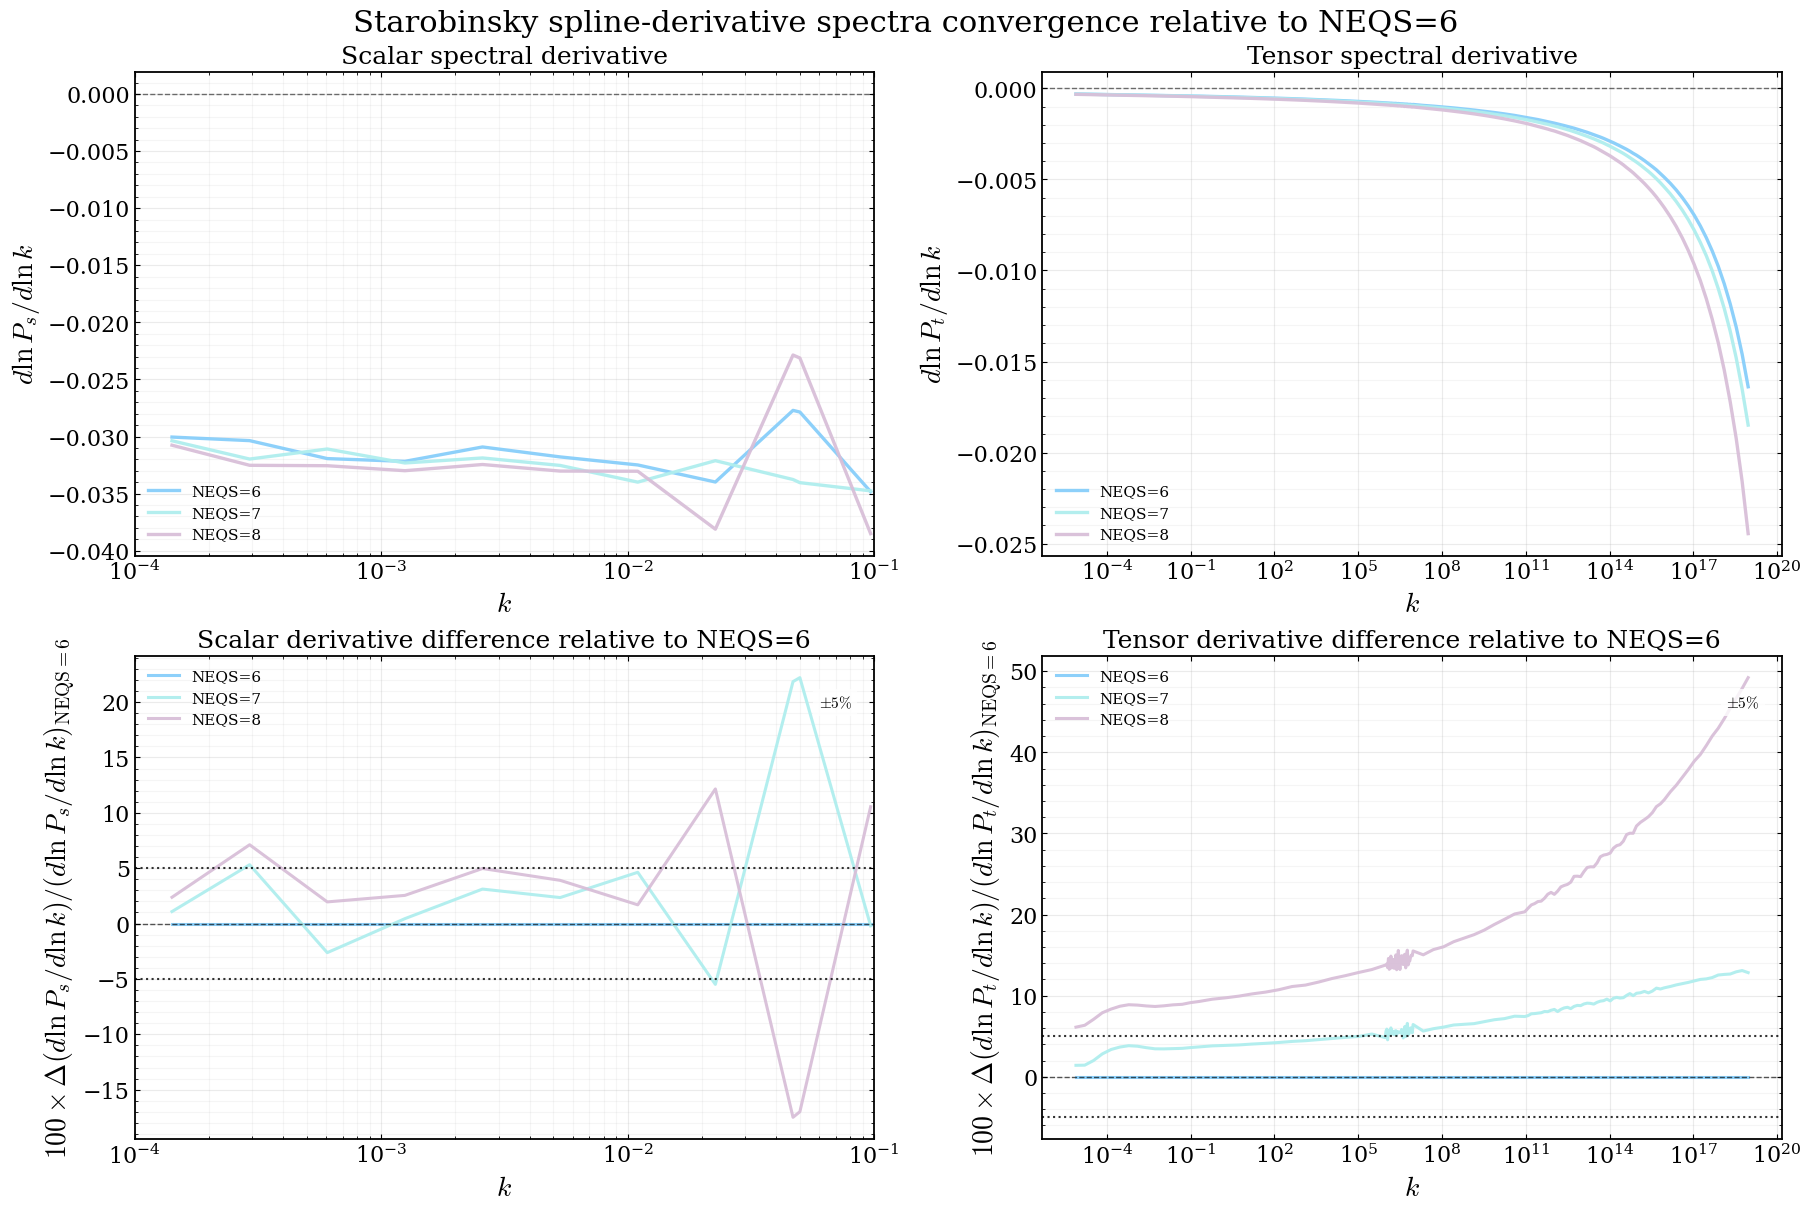


=== Base spectra derivative convergence summary ===
 NEQS param_name  mean_abs_dlnPs_pct  max_abs_dlnPs_pct  mean_abs_dlnPt_pct  max_abs_dlnPt_pct
    6       lam3            0.000000           0.000000            0.000000           0.000000
    7       lam4            6.300147          22.203335            7.081154          13.094898
    8       lam5            7.430694          17.494111           20.365930          49.209449


In [19]:
deriv_summary_df = plot_base_spectra_derivative_convergence(
    base_path_root=base_path_root,
    ref_NEQS=6,
    k_min_plot_s=1e-4,
    k_max_plot_s=1e-1,
    k_min_plot_t=None,
    k_max_plot_t=None,
    smoothing=0.0,
    tolerance=5.0,
    save_name=None,
)

# deriv_summary_df = plot_base_spectra_derivative_convergence(
#     base_path_root=base_path_root,
#     ref_NEQS=6,
#     k_min_plot_s=1e-4,
#     k_max_plot_s=1e-1,
#     k_min_plot_t=None,
#     k_max_plot_t=None,
#     smoothing=0.0,
#     tolerance=5.0,
#     save_name=f"{MODEL_ID}_spectra_derivative_convergence_neqs6_ref.pdf",
# )

## AFTER SHIFTING:

In [21]:
def test_k_shift_equivalence_scalar_tensor(
    base_path_root,
    base_summary_df,
    ref_NEQS=6,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    tolerance=5.0,
    save_name=None,
    show=True,
):

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    # -------------------------------------------------
    # Truncation orders currently available
    # -------------------------------------------------
    NEQS_LIST = [6, 7, 8]

    if ref_NEQS not in NEQS_LIST:
        raise ValueError(
            f"ref_NEQS={ref_NEQS} not in NEQS_LIST={NEQS_LIST}"
        )

    # -------------------------------------------------
    # Make sure summary dataframe has what we need
    # -------------------------------------------------
    required_cols = {"NEQS", "original_N_end"}

    missing_cols = required_cols - set(base_summary_df.columns)

    if missing_cols:
        raise ValueError(
            f"base_summary_df is missing columns: {missing_cols}"
        )

    # -------------------------------------------------
    # Helper: restrict to desired k window
    # -------------------------------------------------
    def apply_k_window(k, y, kmin=None, kmax=None):

        mask = np.ones_like(k, dtype=bool)

        if kmin is not None:
            mask &= k >= kmin

        if kmax is not None:
            mask &= k <= kmax

        return k[mask], y[mask]

    # -------------------------------------------------
    # Load reference spectra
    # -------------------------------------------------
    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
        ref_NEQS
    )

    # Normalize reference spectra at k_norm
    k_s_ref, Ps_ref, _ = normalize_at_ref(
        k_s_ref_raw,
        Ps_ref_raw,
        k_norm,
    )

    k_t_ref, Pt_ref, _ = normalize_at_ref(
        k_t_ref_raw,
        Pt_ref_raw,
        k_norm,
    )

    # -------------------------------------------------
    # Reference N_end
    # -------------------------------------------------
    ref_rows = base_summary_df.loc[
        base_summary_df["NEQS"] == ref_NEQS
    ]

    if len(ref_rows) == 0:
        raise ValueError(
            f"No NEQS={ref_NEQS} row found in base_summary_df"
        )

    ref_N_end = ref_rows["original_N_end"].iloc[0]

    print(
        f"\nReference NEQS={ref_NEQS}: "
        f"N_end={ref_N_end:.10f}"
    )

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_s, ax_t = axes[0]
    ax_s_err, ax_t_err = axes[1]

    # -------------------------------------------------
    # Plot reference spectra
    # -------------------------------------------------
    k_s_ref_plot, Ps_ref_plot = apply_k_window(
        k_s_ref,
        Ps_ref,
        kmin=k_min_scalar,
        kmax=k_max_scalar,
    )

    ax_s.loglog(
        k_s_ref_plot,
        Ps_ref_plot,
        lw=3.2,
        color="black",
        linestyle="--",
        label=rf"NEQS={ref_NEQS} reference",
    )

    ax_t.loglog(
        k_t_ref,
        Pt_ref,
        lw=3.2,
        color="black",
        linestyle="--",
        label=rf"NEQS={ref_NEQS} reference",
    )

    rows = []

    # -------------------------------------------------
    # Compare higher-order truncations
    # -------------------------------------------------
    for NEQS in NEQS_LIST:

        if NEQS == ref_NEQS:
            continue

        param_name, param_label = SCAN_INFO[NEQS]

        # -------------------------------------------------
        # Get N_end for this truncation
        # -------------------------------------------------
        neqs_rows = base_summary_df.loc[
            base_summary_df["NEQS"] == NEQS
        ]

        if len(neqs_rows) == 0:
            raise ValueError(
                f"No NEQS={NEQS} row found in base_summary_df"
            )

        N_end = neqs_rows["original_N_end"].iloc[0]

        # Difference relative to reference truncation
        deltaN = N_end - ref_N_end

        shift_factor = np.exp(-deltaN)

        print(f"\nNEQS={NEQS}")
        print(f"  N_end           = {N_end:.10f}")
        print(f"  reference N_end = {ref_N_end:.10f}")
        print(f"  deltaN          = {deltaN:.10f}")
        print(f"  exp(-deltaN)    = {shift_factor:.10e}")

        # -------------------------------------------------
        # Load spectra
        # -------------------------------------------------
        k_s, Ps, k_t, Pt = load_specs(
            NEQS
        )

        # -------------------------------------------------
        # Apply k shift
        # -------------------------------------------------
        k_s_shifted = k_s * shift_factor
        k_t_shifted = k_t * shift_factor

        # -------------------------------------------------
        # Re-normalize AFTER shifting k
        # -------------------------------------------------
        k_s_shifted, Ps_shifted_norm, _ = normalize_at_ref(
            k_s_shifted,
            Ps,
            k_norm,
        )

        k_t_shifted, Pt_shifted_norm, _ = normalize_at_ref(
            k_t_shifted,
            Pt,
            k_norm,
        )

        color = colors.get(
            NEQS,
            None
        )

        label = (
            rf"NEQS={NEQS}, "
            rf"$\Delta N={deltaN:.2f}$"
        )

        # -------------------------------------------------
        # Scalar plotting window
        # -------------------------------------------------
        k_s_plot, Ps_plot = apply_k_window(
            k_s_shifted,
            Ps_shifted_norm,
            kmin=k_min_scalar,
            kmax=k_max_scalar,
        )

        # -------------------------------------------------
        # Plot shifted spectra
        # -------------------------------------------------
        ax_s.loglog(
            k_s_plot,
            Ps_plot,
            lw=2.5,
            linestyle="-",
            color=color,
            label=label,
        )

        ax_t.loglog(
            k_t_shifted,
            Pt_shifted_norm,
            lw=2.5,
            linestyle="-",
            color=color,
            label=label,
        )

        # -------------------------------------------------
        # Fractional differences vs NEQS reference
        # -------------------------------------------------
        k_s_frac, frac_s = fractional_difference_on_overlap(
            k_s_shifted,
            Ps_shifted_norm,
            k_s_ref,
            Ps_ref,
        )

        k_t_frac, frac_t = fractional_difference_on_overlap(
            k_t_shifted,
            Pt_shifted_norm,
            k_t_ref,
            Pt_ref,
        )

        # Apply scalar k window to fractional errors
        k_s_frac, frac_s = apply_k_window(
            k_s_frac,
            frac_s,
            kmin=k_min_scalar,
            kmax=k_max_scalar,
        )

        ax_s_err.semilogx(
            k_s_frac,
            100.0 * frac_s,
            lw=2.2,
            color=color,
            label=rf"NEQS={NEQS}",
        )

        ax_t_err.semilogx(
            k_t_frac,
            100.0 * frac_t,
            lw=2.2,
            color=color,
            label=rf"NEQS={NEQS}",
        )

        # -------------------------------------------------
        # Save summary information
        # -------------------------------------------------
        rows.append({
            "NEQS": NEQS,
            "param_name": param_name,

            "original_N_end": N_end,
            "ref_N_end": ref_N_end,

            "deltaN_from_ref": deltaN,
            "k_shift_factor": shift_factor,

            "mean_abs_dPs_pct":
                100.0 * np.nanmean(np.abs(frac_s)),

            "max_abs_dPs_pct":
                100.0 * np.nanmax(np.abs(frac_s)),

            "mean_abs_dPt_pct":
                100.0 * np.nanmean(np.abs(frac_t)),

            "max_abs_dPt_pct":
                100.0 * np.nanmax(np.abs(frac_t)),
        })

    # -------------------------------------------------
    # Reference k
    # -------------------------------------------------
    for ax in [ax_s, ax_t]:

        ax.axvline(
            k_norm,
            color="black",
            ls=":",
            lw=1.3,
            alpha=0.7,
        )

    # -------------------------------------------------
    # Fractional-error reference/tolerance lines
    # -------------------------------------------------
    for ax in [ax_s_err, ax_t_err]:

        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.1,
            alpha=0.7,
        )

        ax.axhline(
            tolerance,
            color="black",
            ls=":",
            lw=1.4,
            alpha=0.85,
        )

        ax.axhline(
            -tolerance,
            color="black",
            ls=":",
            lw=1.4,
            alpha=0.85,
        )

        ax.text(
            0.97,
            0.92,
            rf"$\pm {tolerance:.0f}\%$",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.85,
            ),
        )

    # -------------------------------------------------
    # Titles
    # -------------------------------------------------
    ax_s.set_title(
        r"Scalar spectra after "
        r"$k\rightarrow k e^{-\Delta N}$"
    )

    ax_t.set_title(
        r"Tensor spectra after "
        r"$k\rightarrow k e^{-\Delta N}$"
    )

    ax_s_err.set_title(
        rf"Scalar fractional difference relative to NEQS={ref_NEQS}"
    )

    ax_t_err.set_title(
        rf"Tensor fractional difference relative to NEQS={ref_NEQS}"
    )

    # -------------------------------------------------
    # Axis labels
    # -------------------------------------------------
    ax_s.set_xlabel(r"shifted $k$")
    ax_t.set_xlabel(r"shifted $k$")
    ax_s_err.set_xlabel(r"shifted $k$")
    ax_t_err.set_xlabel(r"shifted $k$")

    ax_s.set_ylabel(
        rf"$P_s/P_s(k={k_norm})$"
    )

    ax_t.set_ylabel(
        rf"$P_t/P_t(k={k_norm})$"
    )

    ax_s_err.set_ylabel(
        rf"$100\times\Delta P_s/"
        rf"P_{{s,\rm NEQS={ref_NEQS}}}$"
    )

    ax_t_err.set_ylabel(
        rf"$100\times\Delta P_t/"
        rf"P_{{t,\rm NEQS={ref_NEQS}}}$"
    )

    # -------------------------------------------------
    # Scalar k limits
    # -------------------------------------------------
    ax_s.set_xlim(
        k_min_scalar,
        k_max_scalar
    )

    ax_s_err.set_xlim(
        k_min_scalar,
        k_max_scalar
    )

    # -------------------------------------------------
    # Styling
    # -------------------------------------------------
    for ax in axes.ravel():

        ax.grid(
            True,
            which="major",
            alpha=0.25
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12
        )

        ax.minorticks_on()

        handles, labels = ax.get_legend_handles_labels()

        if len(handles) > 0:
            ax.legend(
                frameon=False,
                fontsize=11,
                loc="lower left",
            )

    # -------------------------------------------------
    # Overall title
    # -------------------------------------------------
    fig.suptitle(
        rf"{MODEL_ID.capitalize()}: testing whether spectra "
        rf"differ mainly by a $k$-shift",
        fontsize=22,
    )

    # -------------------------------------------------
    # Optional save
    # -------------------------------------------------
    if save_name is not None:

        fig.savefig(
            save_name,
            dpi=300,
            bbox_inches="tight",
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

    # -------------------------------------------------
    # Summary
    # -------------------------------------------------
    summary_df = pd.DataFrame(rows)

    print("\n=== Shifted base spectra summary ===")
    print(summary_df.to_string(index=False))

    return summary_df

In [24]:
def load_base_summary_df(base_path_root, model_id, NEQS_LIST=(6, 7, 8)):

    rows = []

    for NEQS in NEQS_LIST:

        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}_nonhiggs_{model_id}",
            f"neqs{NEQS}_summary.csv",
        )

        if not os.path.exists(summary_file):
            raise FileNotFoundError(
                f"Missing summary file:\n{summary_file}"
            )

        df = pd.read_csv(summary_file)

        if len(df) == 0:
            raise ValueError(
                f"Summary file is empty:\n{summary_file}"
            )

        # We currently expect one accepted base model per NEQS
        row = df.iloc[0].copy()

        row["NEQS"] = NEQS

        rows.append(row)

    base_summary_df = pd.DataFrame(rows)

    return base_summary_df

In [25]:
base_summary_df = load_base_summary_df(
    base_path_root=base_path_root,
    model_id=MODEL_ID,
)

print(
    base_summary_df[
        [
            "NEQS",
            "original_N_end",
            "r",
            "n_s",
            "alpha_s",
        ]
    ].to_string(index=False)
)

 NEQS  original_N_end        r      n_s   alpha_s
    6      945.906500 0.002756 0.969087 -0.000390
    7      944.856254 0.002847 0.968661 -0.000417
    8      943.364368 0.002985 0.968008 -0.000459



Reference NEQS=6: N_end=945.9064998424

NEQS=7
  N_end           = 944.8562536950
  reference N_end = 945.9064998424
  deltaN          = -1.0502461474
  exp(-deltaN)    = 2.8583546082e+00

NEQS=8
  N_end           = 943.3643678385
  reference N_end = 945.9064998424
  deltaN          = -2.5421320039
  exp(-deltaN)    = 1.2706732917e+01


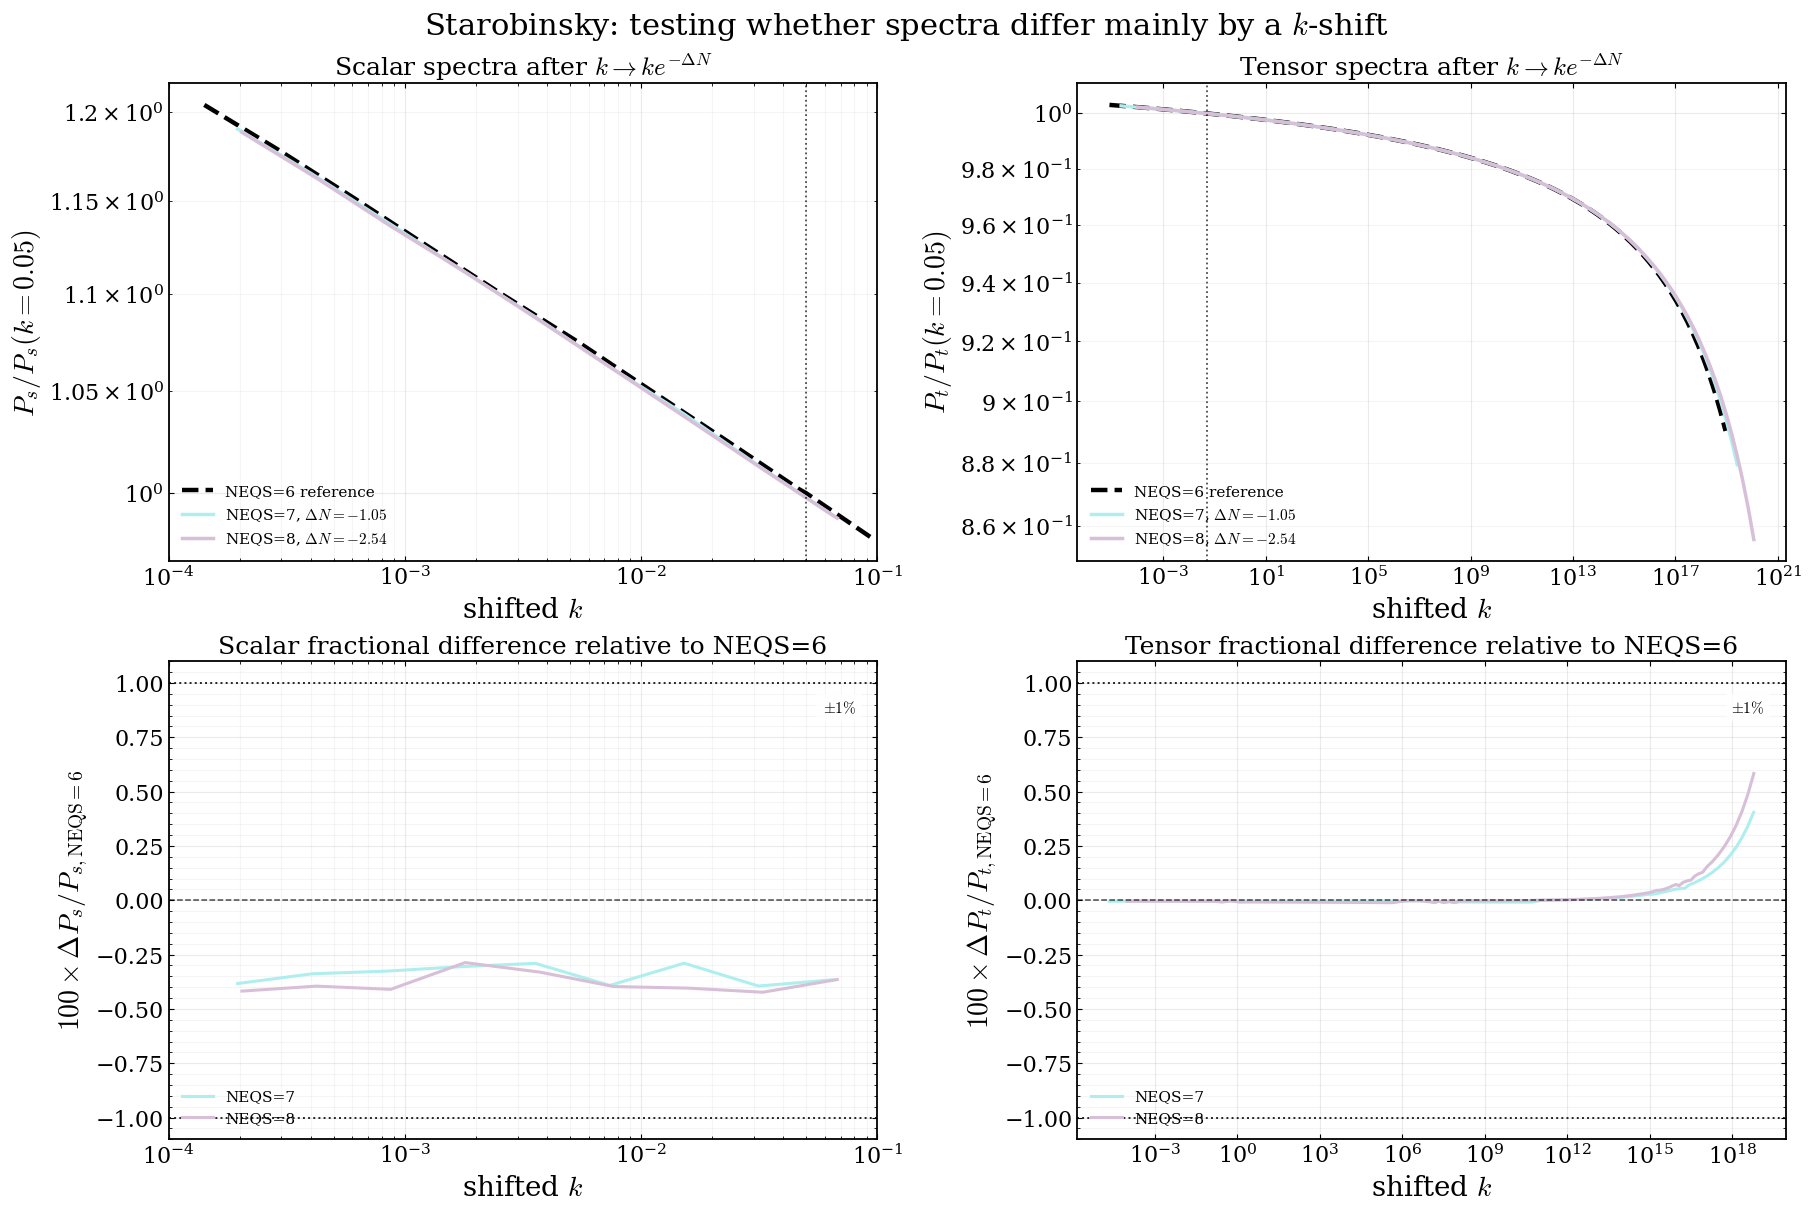


=== Shifted base spectra summary ===
 NEQS param_name  original_N_end  ref_N_end  deltaN_from_ref  k_shift_factor  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    7       lam4      944.856254   945.9065        -1.050246        2.858355          0.342857         0.394817          0.026530         0.404888
    8       lam5      943.364368   945.9065        -2.542132       12.706733          0.381138         0.423268          0.039442         0.583401


In [26]:
kshift_summary_df = test_k_shift_equivalence_scalar_tensor(
    base_path_root=base_path_root,
    base_summary_df=base_summary_df,
    ref_NEQS=6,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    tolerance=1.0,
    save_name=None,
)

# save_name=f"{MODEL_ID}_scalar_tensor_kshift_equivalence_neqs6_ref.pdf"

In [27]:
def plot_base_spectra_derivatives_bspline_2x2_kshifted(
    base_path_root,
    base_summary_df,
    ref_NEQS=6,
    apply_k_shift=True,
    k_min_plot_s=1e-4,
    k_max_plot_s=1e-1,
    k_min_plot_t=None,
    k_max_plot_t=None,
    smoothing=0.0,
    save_name=None,
    show=True,
):

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,

        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    # -------------------------------------------------
    # Truncation orders currently available
    # -------------------------------------------------
    NEQS_LIST = [6, 7, 8]

    if ref_NEQS not in NEQS_LIST:
        raise ValueError(
            f"ref_NEQS={ref_NEQS} not in NEQS_LIST={NEQS_LIST}"
        )

    # -------------------------------------------------
    # Pull N_end from summary dataframe
    # -------------------------------------------------
    def get_N_end(summary_df, NEQS):

        matches = summary_df.loc[
            summary_df["NEQS"].astype(int) == int(NEQS)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No original_N_end found for NEQS={NEQS}"
            )

        return float(
            matches.iloc[0]["original_N_end"]
        )

    # -------------------------------------------------
    # Build spline derivatives in log-space
    # -------------------------------------------------
    def prepare_log_spline(k, P, smoothing=0.0):

        k = np.asarray(k)
        P = np.asarray(P)

        mask = (
            (k > 0)
            & (P > 0)
            & np.isfinite(k)
            & np.isfinite(P)
        )

        k = k[mask]
        P = P[mask]

        order = np.argsort(k)
        k = k[order]
        P = P[order]

        x = np.log(k)
        y = np.log(P)

        x_unique = np.unique(x)

        y_unique = np.array([
            np.mean(y[x == xu])
            for xu in x_unique
        ])

        if len(x_unique) < 4:
            raise ValueError(
                "Need at least 4 unique k values for cubic spline."
            )

        spl = UnivariateSpline(
            x_unique,
            y_unique,
            s=smoothing,
            k=3,
        )

        d1 = spl.derivative(1)(x_unique)
        d2 = spl.derivative(2)(x_unique)

        return np.exp(x_unique), d1, d2

    # -------------------------------------------------
    # Apply k plotting window
    # -------------------------------------------------
    def apply_k_window(
        k,
        y,
        kmin=None,
        kmax=None,
    ):

        mask = np.ones_like(
            k,
            dtype=bool,
        )

        if kmin is not None:
            mask &= k >= kmin

        if kmax is not None:
            mask &= k <= kmax

        return k[mask], y[mask]

    # -------------------------------------------------
    # Reference N_end
    # -------------------------------------------------
    ref_N_end = get_N_end(
        base_summary_df,
        ref_NEQS,
    )

    print(
        f"\nReference NEQS={ref_NEQS}: "
        f"N_end={ref_N_end:.10f}"
    )

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_d1Ps, ax_d1Pt = axes[0]
    ax_d2Ps, ax_d2Pt = axes[1]

    rows = []

    # -------------------------------------------------
    # Loop over truncation orders
    # -------------------------------------------------
    for NEQS in NEQS_LIST:

        param_name, param_label = SCAN_INFO[NEQS]

        # Generic spectrum loader
        k_s, Ps, k_t, Pt = load_specs(
            NEQS
        )

        # -------------------------------------------------
        # Compute N shift
        # -------------------------------------------------
        N_end = get_N_end(
            base_summary_df,
            NEQS,
        )

        if apply_k_shift:

            deltaN = N_end - ref_N_end
            shift_factor = np.exp(-deltaN)

            k_s = k_s * shift_factor
            k_t = k_t * shift_factor

        else:

            deltaN = 0.0
            shift_factor = 1.0

        print(f"\nNEQS={NEQS}")
        print(f"  N_end           = {N_end:.10f}")
        print(f"  reference N_end = {ref_N_end:.10f}")
        print(f"  deltaN          = {deltaN:.10f}")
        print(f"  exp(-deltaN)    = {shift_factor:.10e}")

        # -------------------------------------------------
        # Derivatives
        # -------------------------------------------------
        k_s_use, d1Ps, d2Ps = prepare_log_spline(
            k_s,
            Ps,
            smoothing=smoothing,
        )

        k_t_use, d1Pt, d2Pt = prepare_log_spline(
            k_t,
            Pt,
            smoothing=smoothing,
        )

        # -------------------------------------------------
        # Apply plotting windows
        # -------------------------------------------------
        k_s_d1, d1Ps_plot = apply_k_window(
            k_s_use,
            d1Ps,
            kmin=k_min_plot_s,
            kmax=k_max_plot_s,
        )

        k_s_d2, d2Ps_plot = apply_k_window(
            k_s_use,
            d2Ps,
            kmin=k_min_plot_s,
            kmax=k_max_plot_s,
        )

        k_t_d1, d1Pt_plot = apply_k_window(
            k_t_use,
            d1Pt,
            kmin=k_min_plot_t,
            kmax=k_max_plot_t,
        )

        k_t_d2, d2Pt_plot = apply_k_window(
            k_t_use,
            d2Pt,
            kmin=k_min_plot_t,
            kmax=k_max_plot_t,
        )

        color = colors.get(
            NEQS,
            None
        )

        if apply_k_shift:
            label = (
                rf"NEQS={NEQS}, "
                rf"$\Delta N={deltaN:.2f}$"
            )
        else:
            label = rf"NEQS={NEQS}"

        # -------------------------------------------------
        # Plot first derivatives
        # -------------------------------------------------
        ax_d1Ps.semilogx(
            k_s_d1,
            d1Ps_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        ax_d1Pt.semilogx(
            k_t_d1,
            d1Pt_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        # -------------------------------------------------
        # Plot second derivatives
        # -------------------------------------------------
        ax_d2Ps.semilogx(
            k_s_d2,
            d2Ps_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        ax_d2Pt.semilogx(
            k_t_d2,
            d2Pt_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        # -------------------------------------------------
        # Store summary info
        # -------------------------------------------------
        rows.append({
            "NEQS": NEQS,
            "param_name": param_name,

            "original_N_end": N_end,
            "ref_N_end": ref_N_end,

            "deltaN_from_ref": deltaN,
            "exp_minus_deltaN": shift_factor,

            "k_s_min_shifted":
                np.nanmin(k_s_use),

            "k_s_max_shifted":
                np.nanmax(k_s_use),

            "k_t_min_shifted":
                np.nanmin(k_t_use),

            "k_t_max_shifted":
                np.nanmax(k_t_use),
        })

    # -------------------------------------------------
    # Shift label
    # -------------------------------------------------
    shift_label = (
        r"$k \rightarrow k e^{-\Delta N}$"
        if apply_k_shift
        else r"no $k$ shift"
    )

    # -------------------------------------------------
    # Titles
    # -------------------------------------------------
    ax_d1Ps.set_title(
        rf"Scalar first derivative after {shift_label}"
    )

    ax_d1Pt.set_title(
        rf"Tensor first derivative after {shift_label}"
    )

    ax_d2Ps.set_title(
        rf"Scalar second derivative after {shift_label}"
    )

    ax_d2Pt.set_title(
        rf"Tensor second derivative after {shift_label}"
    )

    # -------------------------------------------------
    # Labels
    # -------------------------------------------------
    ax_d1Ps.set_ylabel(
        r"$d\ln P_s/d\ln k$"
    )

    ax_d1Pt.set_ylabel(
        r"$d\ln P_t/d\ln k$"
    )

    ax_d2Ps.set_ylabel(
        r"$d^2\ln P_s/d(\ln k)^2$"
    )

    ax_d2Pt.set_ylabel(
        r"$d^2\ln P_t/d(\ln k)^2$"
    )

    # -------------------------------------------------
    # Styling
    # -------------------------------------------------
    for ax in axes.ravel():

        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.55,
        )

        ax.set_xlabel(
            r"shifted $k$"
            if apply_k_shift
            else r"$k$"
        )

        ax.grid(
            True,
            which="major",
            alpha=0.25
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12
        )

        ax.minorticks_on()

        handles, labels = ax.get_legend_handles_labels()

        if len(handles) > 0:
            ax.legend(
                frameon=False,
                fontsize=11,
                loc="best",
            )

    # -------------------------------------------------
    # Scalar limits
    # -------------------------------------------------
    if (
        k_min_plot_s is not None
        or k_max_plot_s is not None
    ):

        xmin_s = (
            k_min_plot_s
            if k_min_plot_s is not None
            else None
        )

        xmax_s = (
            k_max_plot_s
            if k_max_plot_s is not None
            else None
        )

        ax_d1Ps.set_xlim(
            xmin_s,
            xmax_s
        )

        ax_d2Ps.set_xlim(
            xmin_s,
            xmax_s
        )

    # -------------------------------------------------
    # Tensor limits
    # -------------------------------------------------
    if (
        k_min_plot_t is not None
        or k_max_plot_t is not None
    ):

        xmin_t = (
            k_min_plot_t
            if k_min_plot_t is not None
            else None
        )

        xmax_t = (
            k_max_plot_t
            if k_max_plot_t is not None
            else None
        )

        ax_d1Pt.set_xlim(
            xmin_t,
            xmax_t
        )

        ax_d2Pt.set_xlim(
            xmin_t,
            xmax_t
        )

    # -------------------------------------------------
    # Overall title
    # -------------------------------------------------
    fig.suptitle(
        rf"{MODEL_ID.capitalize()} B-spline spectral derivatives "
        rf"after {shift_label}",
        fontsize=22,
    )

    # -------------------------------------------------
    # Optional save
    # -------------------------------------------------
    if save_name is not None:

        fig.savefig(
            save_name,
            dpi=300,
            bbox_inches="tight",
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

    # -------------------------------------------------
    # Summary dataframe
    # -------------------------------------------------
    summary_df = pd.DataFrame(rows)

    print(
        "\n=== Shifted derivative summary ==="
    )

    print(
        summary_df.to_string(index=False)
    )

    return summary_df



Reference NEQS=6: N_end=945.9064998424

NEQS=6
  N_end           = 945.9064998424
  reference N_end = 945.9064998424
  deltaN          = 0.0000000000
  exp(-deltaN)    = 1.0000000000e+00

NEQS=7
  N_end           = 944.8562536950
  reference N_end = 945.9064998424
  deltaN          = -1.0502461474
  exp(-deltaN)    = 2.8583546082e+00

NEQS=8
  N_end           = 943.3643678385
  reference N_end = 945.9064998424
  deltaN          = -2.5421320039
  exp(-deltaN)    = 1.2706732917e+01


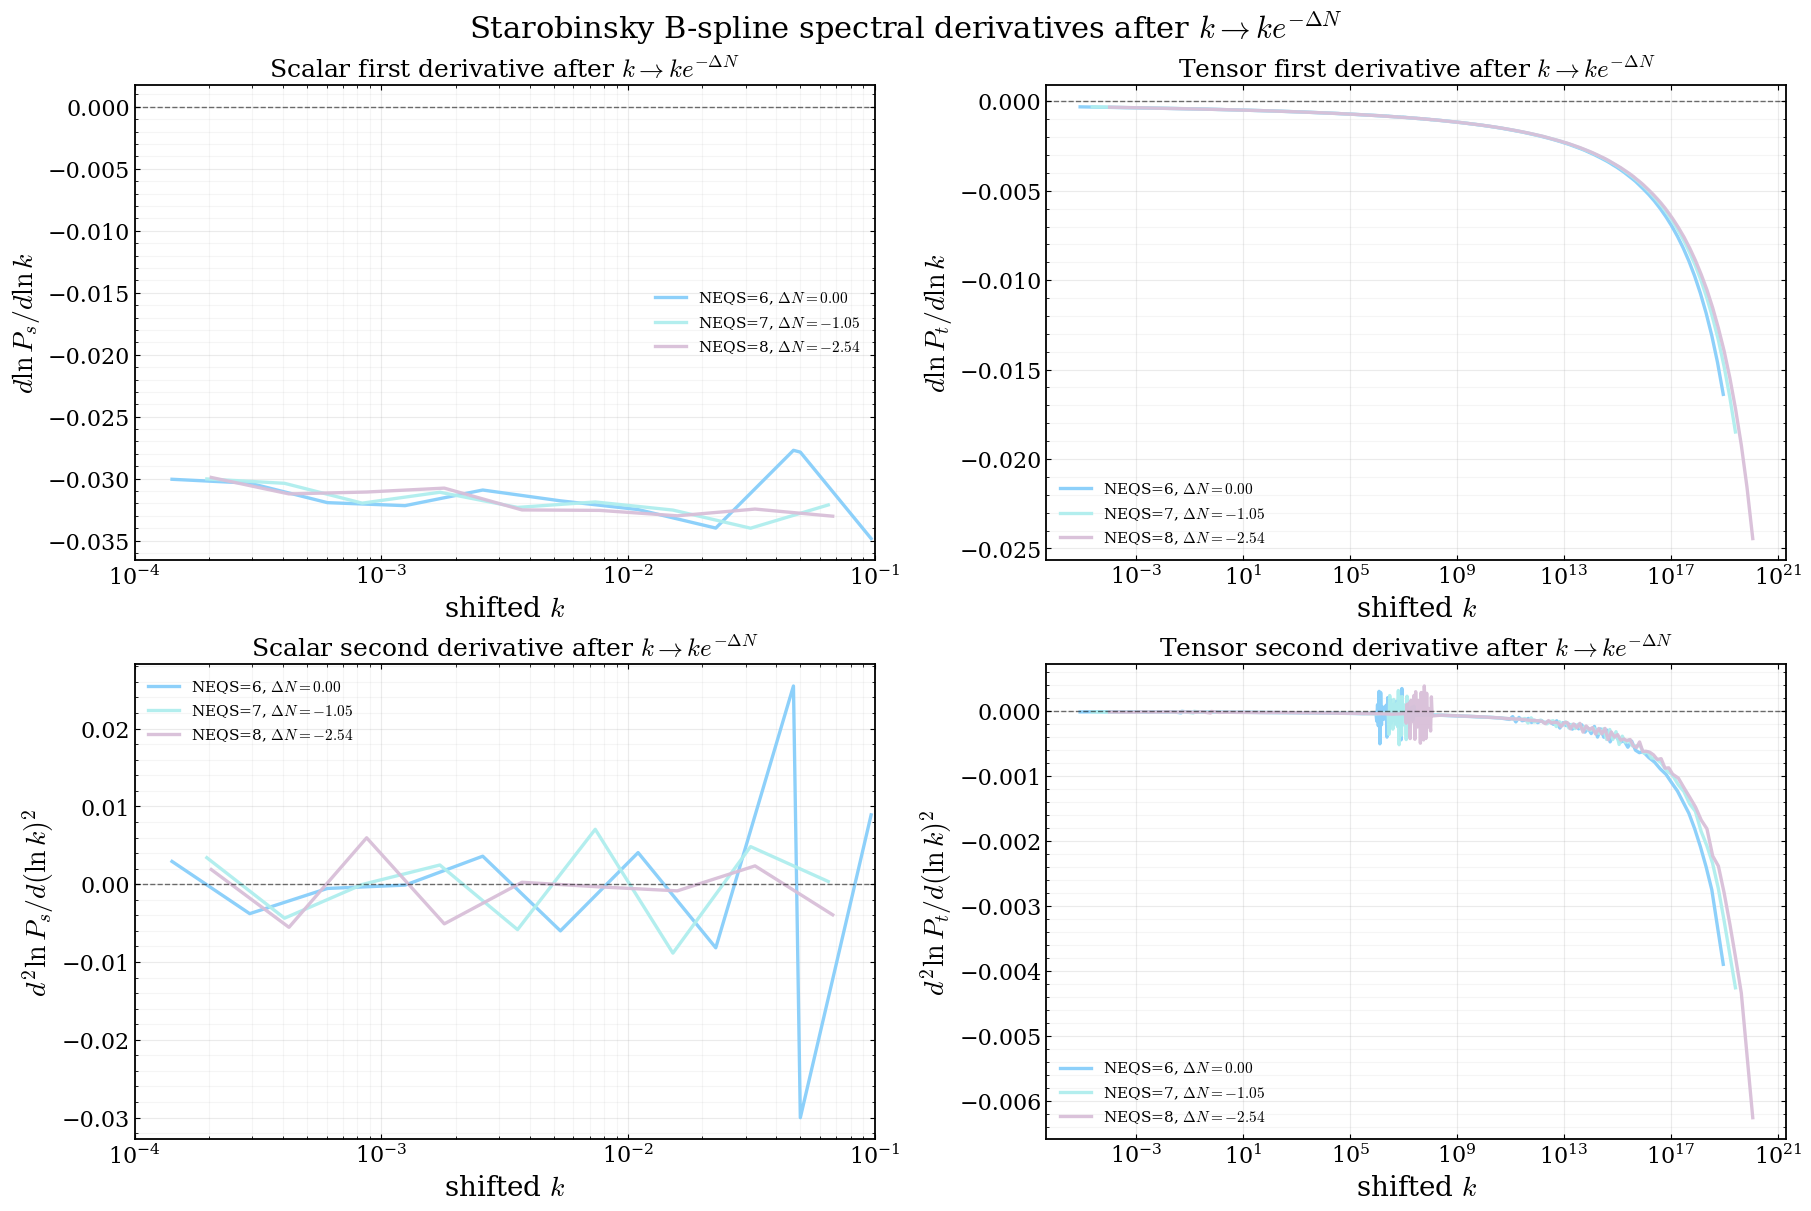


=== Shifted derivative summary ===
 NEQS param_name  original_N_end  ref_N_end  deltaN_from_ref  exp_minus_deltaN  k_s_min_shifted  k_s_max_shifted  k_t_min_shifted  k_t_max_shifted
    6       lam3      945.906500   945.9065         0.000000          1.000000         0.000008     9.238717e+18         0.000008     9.238717e+18
    7       lam4      944.856254   945.9065        -1.050246          2.858355         0.000022     2.640753e+19         0.000022     2.640753e+19
    8       lam5      943.364368   945.9065        -2.542132         12.706733         0.000099     1.173939e+20         0.000099     1.173939e+20


In [28]:
deriv_shift_summary_df = (
    plot_base_spectra_derivatives_bspline_2x2_kshifted(
        base_path_root=base_path_root,
        base_summary_df=base_summary_df,
        ref_NEQS=6,
        apply_k_shift=True,
        k_min_plot_s=1e-4,
        k_max_plot_s=1e-1,
        k_min_plot_t=None,
        k_max_plot_t=None,
        smoothing=0.0,
        save_name=None,
    )
)

# save_name=(
#     f"{MODEL_ID}_spectra_derivatives_"
#     f"neqs6_8_kshifted.pdf"
# )

# Convergence Run Suite

In [29]:
def run_model_convergence_suite(
    model_id,
    base_path_root,
    ref_NEQS=6,
    save_plots=True,
    show_plots=True,
    run_background=True,
    run_spectra=True,
    run_derivative=True,
    run_kshift=True,
    run_shifted_derivative=True,
):

    global MODEL_ID
    global base_dirs

    MODEL_ID = model_id

    NEQS_LIST = [6, 7, 8]

    print("\n" + "=" * 80)
    print(f"RUNNING CONVERGENCE SUITE FOR: {MODEL_ID}")
    print("=" * 80)

    # -------------------------------------------------
    # Rebuild model directories
    # -------------------------------------------------
    base_dirs = {}

    for NEQS in NEQS_LIST:

        folder = get_model_folder(
            NEQS,
            MODEL_ID,
            base_path_root,
        )

        base_dirs[NEQS] = folder

        print(f"NEQS={NEQS}")
        print(f"  {folder}")

    # -------------------------------------------------
    # Load summary dataframe
    # -------------------------------------------------
    base_summary_df = load_base_summary_df(
        base_path_root=base_path_root,
        model_id=MODEL_ID,
        NEQS_LIST=NEQS_LIST,
    )

    print("\nBase summary:")
    print(
        base_summary_df[
            [
                "NEQS",
                "original_N_end",
                "r",
                "n_s",
                "alpha_s",
            ]
        ].to_string(index=False)
    )

    # -------------------------------------------------
    # Helper for filenames
    # -------------------------------------------------
    def make_save_name(tag):

        if not save_plots:
            return None

        return os.path.join(
            base_path_root,
            f"{MODEL_ID}_{tag}.pdf",
        )

    results = {}

    # -------------------------------------------------
    # 1. Background H/V convergence
    # -------------------------------------------------
    if run_background:

        print("\n--- Background H/V convergence ---")

        plot_HV_shape_only_with_frac_error_limitedN(
            base_path_root=base_path_root,
            N_ref=60.0,
            N_min=20.0,
            N_max=60.0,
            save_name=make_save_name(
                "HV_convergence_neqs6_ref"
            ),
        )

    # -------------------------------------------------
    # 2. Raw spectra convergence
    # -------------------------------------------------
    if run_spectra:

        print("\n--- Spectra convergence ---")

        results["spectra"] = (
            plot_base_spectra_overlay_with_frac_errors(
                base_path_root=base_path_root,
                ref_NEQS=ref_NEQS,
                k_ref=0.05,
                k_min_scalar=1e-4,
                k_max_scalar=1e-1,
                tolerance=5.0,
                save_name=make_save_name(
                    "spectra_convergence_neqs6_ref"
                ),
                show=show_plots,
            )
        )

    # -------------------------------------------------
    # 3. Unshifted spectral derivative convergence
    # -------------------------------------------------
    if run_derivative:

        print("\n--- Spectral derivative convergence ---")

        results["derivatives"] = (
            plot_base_spectra_derivative_convergence(
                base_path_root=base_path_root,
                ref_NEQS=ref_NEQS,
                k_min_plot_s=1e-4,
                k_max_plot_s=1e-1,
                k_min_plot_t=None,
                k_max_plot_t=None,
                smoothing=0.0,
                tolerance=5.0,
                save_name=make_save_name(
                    "spectra_derivative_convergence_neqs6_ref"
                ),
                show=show_plots,
            )
        )

    # -------------------------------------------------
    # 4. k-shift equivalence test
    # -------------------------------------------------
    if run_kshift:

        print("\n--- k-shift equivalence test ---")

        results["kshift"] = (
            test_k_shift_equivalence_scalar_tensor(
                base_path_root=base_path_root,
                base_summary_df=base_summary_df,
                ref_NEQS=ref_NEQS,
                k_norm=0.05,
                k_min_scalar=1e-4,
                k_max_scalar=1e-1,
                tolerance=1.0,
                save_name=make_save_name(
                    "spectra_kshift_equivalence_neqs6_ref"
                ),
                show=show_plots,
            )
        )

    # -------------------------------------------------
    # 5. Shifted first/second derivatives
    # -------------------------------------------------
    if run_shifted_derivative:

        print("\n--- Shifted spectral derivatives ---")

        results["shifted_derivatives"] = (
            plot_base_spectra_derivatives_bspline_2x2_kshifted(
                base_path_root=base_path_root,
                base_summary_df=base_summary_df,
                ref_NEQS=ref_NEQS,
                apply_k_shift=True,
                k_min_plot_s=1e-4,
                k_max_plot_s=1e-1,
                k_min_plot_t=None,
                k_max_plot_t=None,
                smoothing=0.0,
                save_name=make_save_name(
                    "spectra_derivatives_kshifted_neqs6_ref"
                ),
                show=show_plots,
            )
        )

    print("\n" + "=" * 80)
    print(f"DONE: {MODEL_ID}")
    print("=" * 80)

    return base_summary_df, results

## For Starobinsky


RUNNING CONVERGENCE SUITE FOR: starobinsky
NEQS=6
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs6_nonhiggs_starobinsky/lam2_2.7701900000e-04_lam3_-1.1798429568e-05_lam4_0.0000000000e+00_lam5_0.0000000000e+00
NEQS=7
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs7_nonhiggs_starobinsky/lam2_2.7701900000e-04_lam3_-1.1798429568e-05_lam4_-4.6184500000e-08_lam5_0.0000000000e+00
NEQS=8
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs8_nonhiggs_starobinsky/lam2_2.7701900000e-04_lam3_-1.1798429568e-05_lam4_-4.6184500000e-08_lam5_1.4171600000e-09

Base summary:
 NEQS  original_N_end        r      n_s   alpha_s
    6      945.906500 0.002756 0.969087 -0.000390
    7      944.856254 0.002847 0.968661 -0.000417
    8      943.364

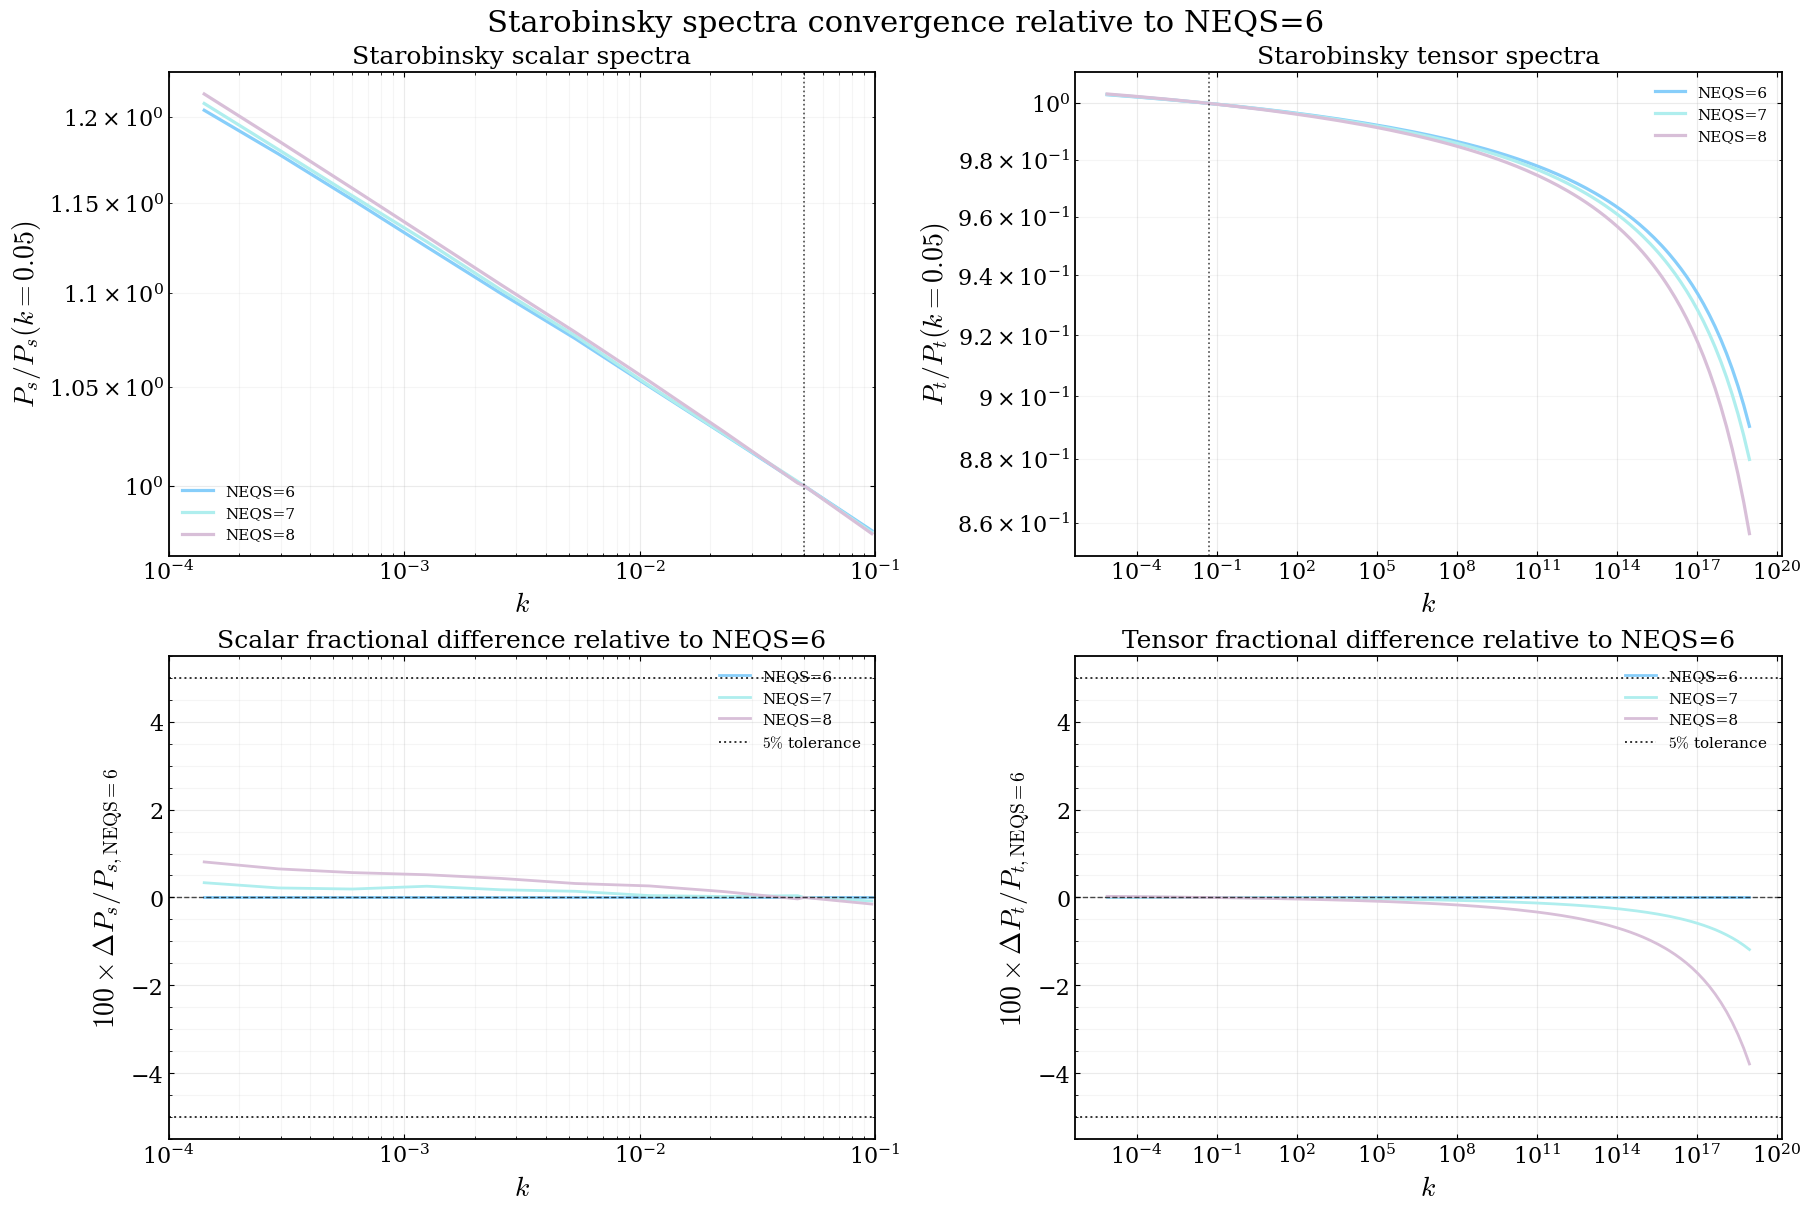


=== Base spectra convergence summary ===
 NEQS param_name  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    6       lam3          0.000000         0.000000          0.000000         0.000000
    7       lam4          0.136684         0.335940          0.178370         1.184483
    8       lam5          0.352152         0.808554          0.507139         3.786303

--- k-shift equivalence test ---

Reference NEQS=6: N_end=945.9064998424

NEQS=7
  N_end           = 944.8562536950
  reference N_end = 945.9064998424
  deltaN          = -1.0502461474
  exp(-deltaN)    = 2.8583546082e+00

NEQS=8
  N_end           = 943.3643678385
  reference N_end = 945.9064998424
  deltaN          = -2.5421320039
  exp(-deltaN)    = 1.2706732917e+01


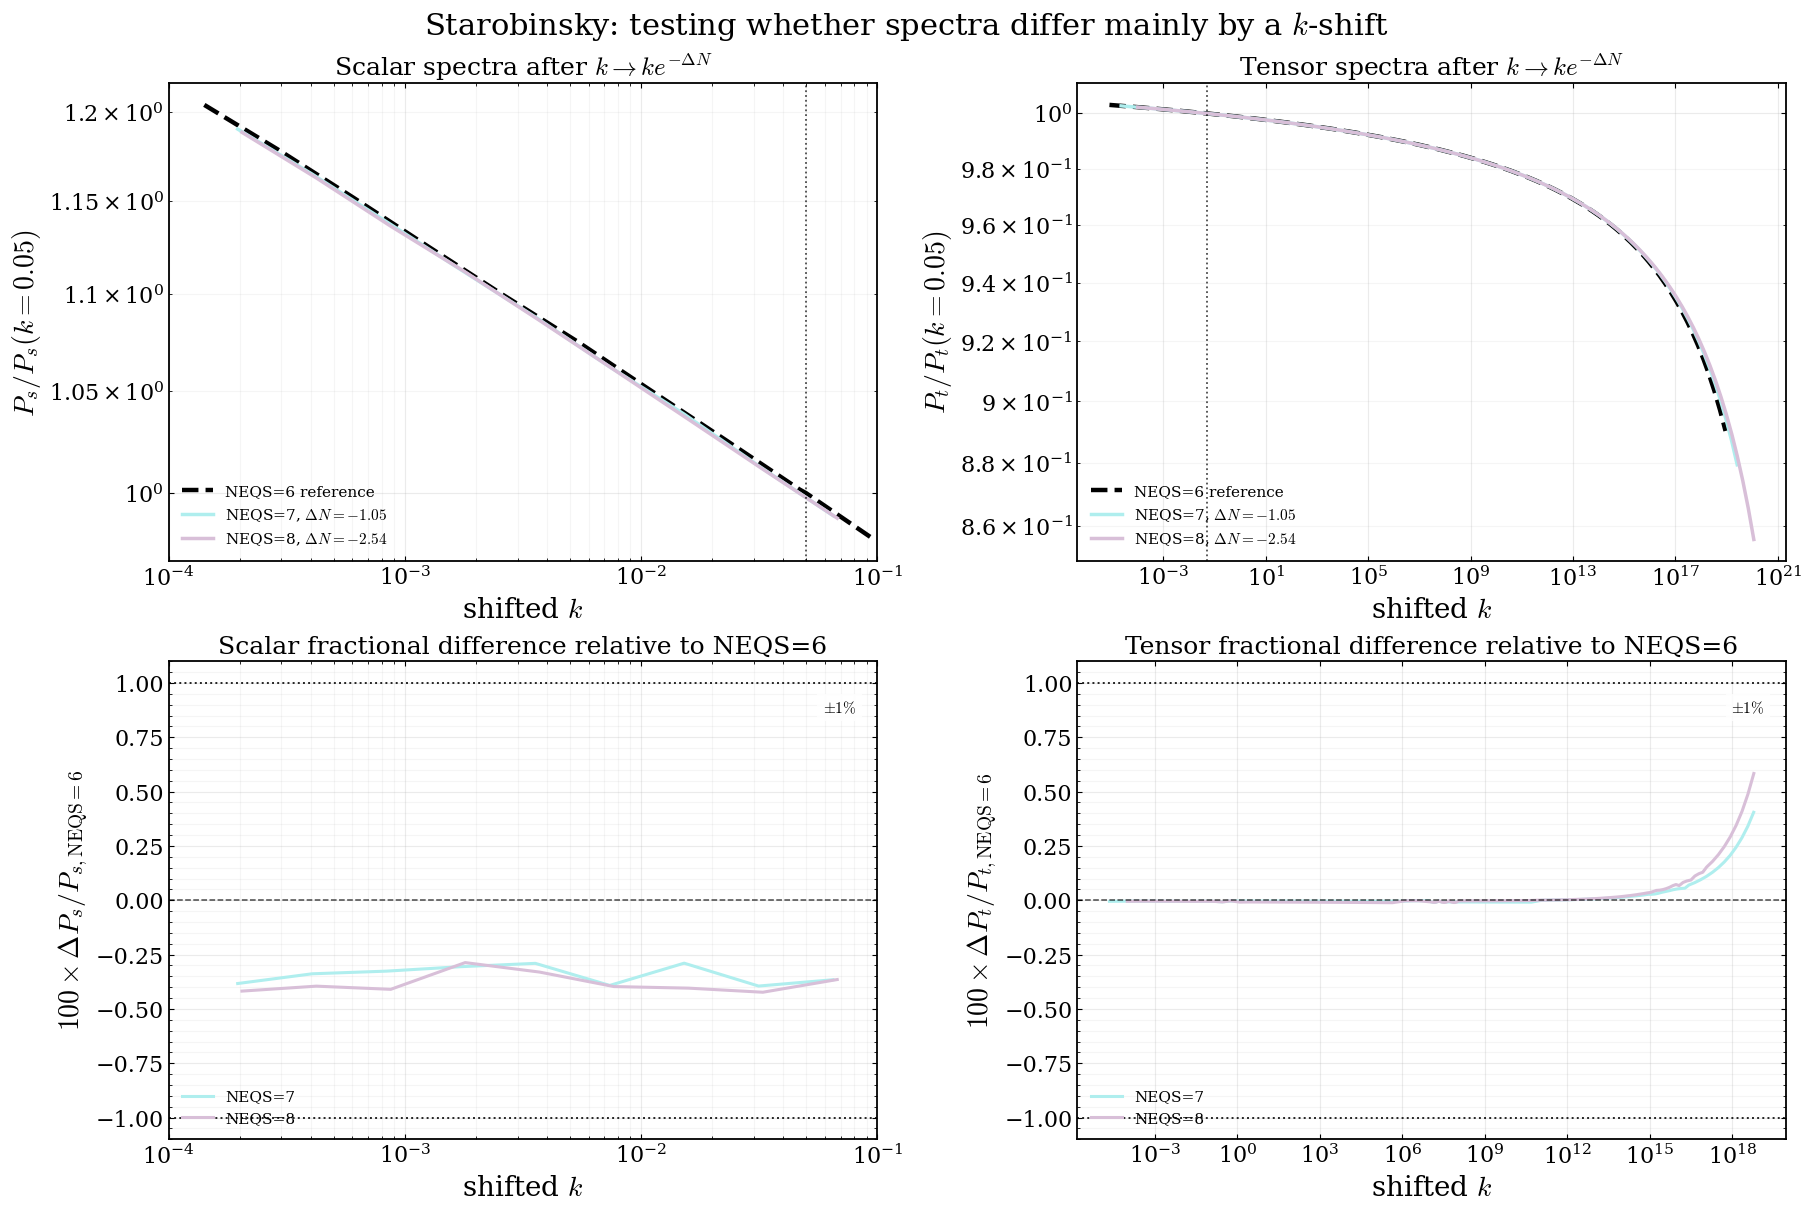


=== Shifted base spectra summary ===
 NEQS param_name  original_N_end  ref_N_end  deltaN_from_ref  k_shift_factor  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    7       lam4      944.856254   945.9065        -1.050246        2.858355          0.342857         0.394817          0.026530         0.404888
    8       lam5      943.364368   945.9065        -2.542132       12.706733          0.381138         0.423268          0.039442         0.583401

DONE: starobinsky


In [31]:
#If I wanna run all of these for a given model
# base_summary_starobinsky, results_starobinsky = run_model_convergence_suite(
#     model_id="starobinsky",
#     base_path_root=base_path_root,
#     ref_NEQS=6,
#     save_plots=True,
#     show_plots=True,
# )

#or if i only want the spectra boys i can do
base_summary_starobinsky, results_starobinsky = run_model_convergence_suite(
    model_id="starobinsky",
    base_path_root=base_path_root,
    ref_NEQS=6,
    save_plots=True,
    show_plots=True,

    run_background=False,
    run_spectra=True,
    run_derivative=False,
    run_kshift=True,
    run_shifted_derivative=False,
)

## For Alpha


RUNNING CONVERGENCE SUITE FOR: alpha
NEQS=6
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs6_nonhiggs_alpha/lam2_2.8990000000e-04_lam3_-4.7865200000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00
NEQS=7
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs7_nonhiggs_alpha/lam2_2.8990000000e-04_lam3_-4.7865200000e-06_lam4_3.7126077175e-06_lam5_0.0000000000e+00
NEQS=8
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs8_nonhiggs_alpha/lam2_2.8990000000e-04_lam3_-4.7865200000e-06_lam4_3.7126077175e-06_lam5_5.5710600000e-10

Base summary:
 NEQS  original_N_end        r      n_s   alpha_s
    6      940.569476 0.003558 0.965585 -0.000593
    7      961.192266 0.002018 0.982455 -0.001262
    8      961.179624 0.002019 0.982445 -0.0

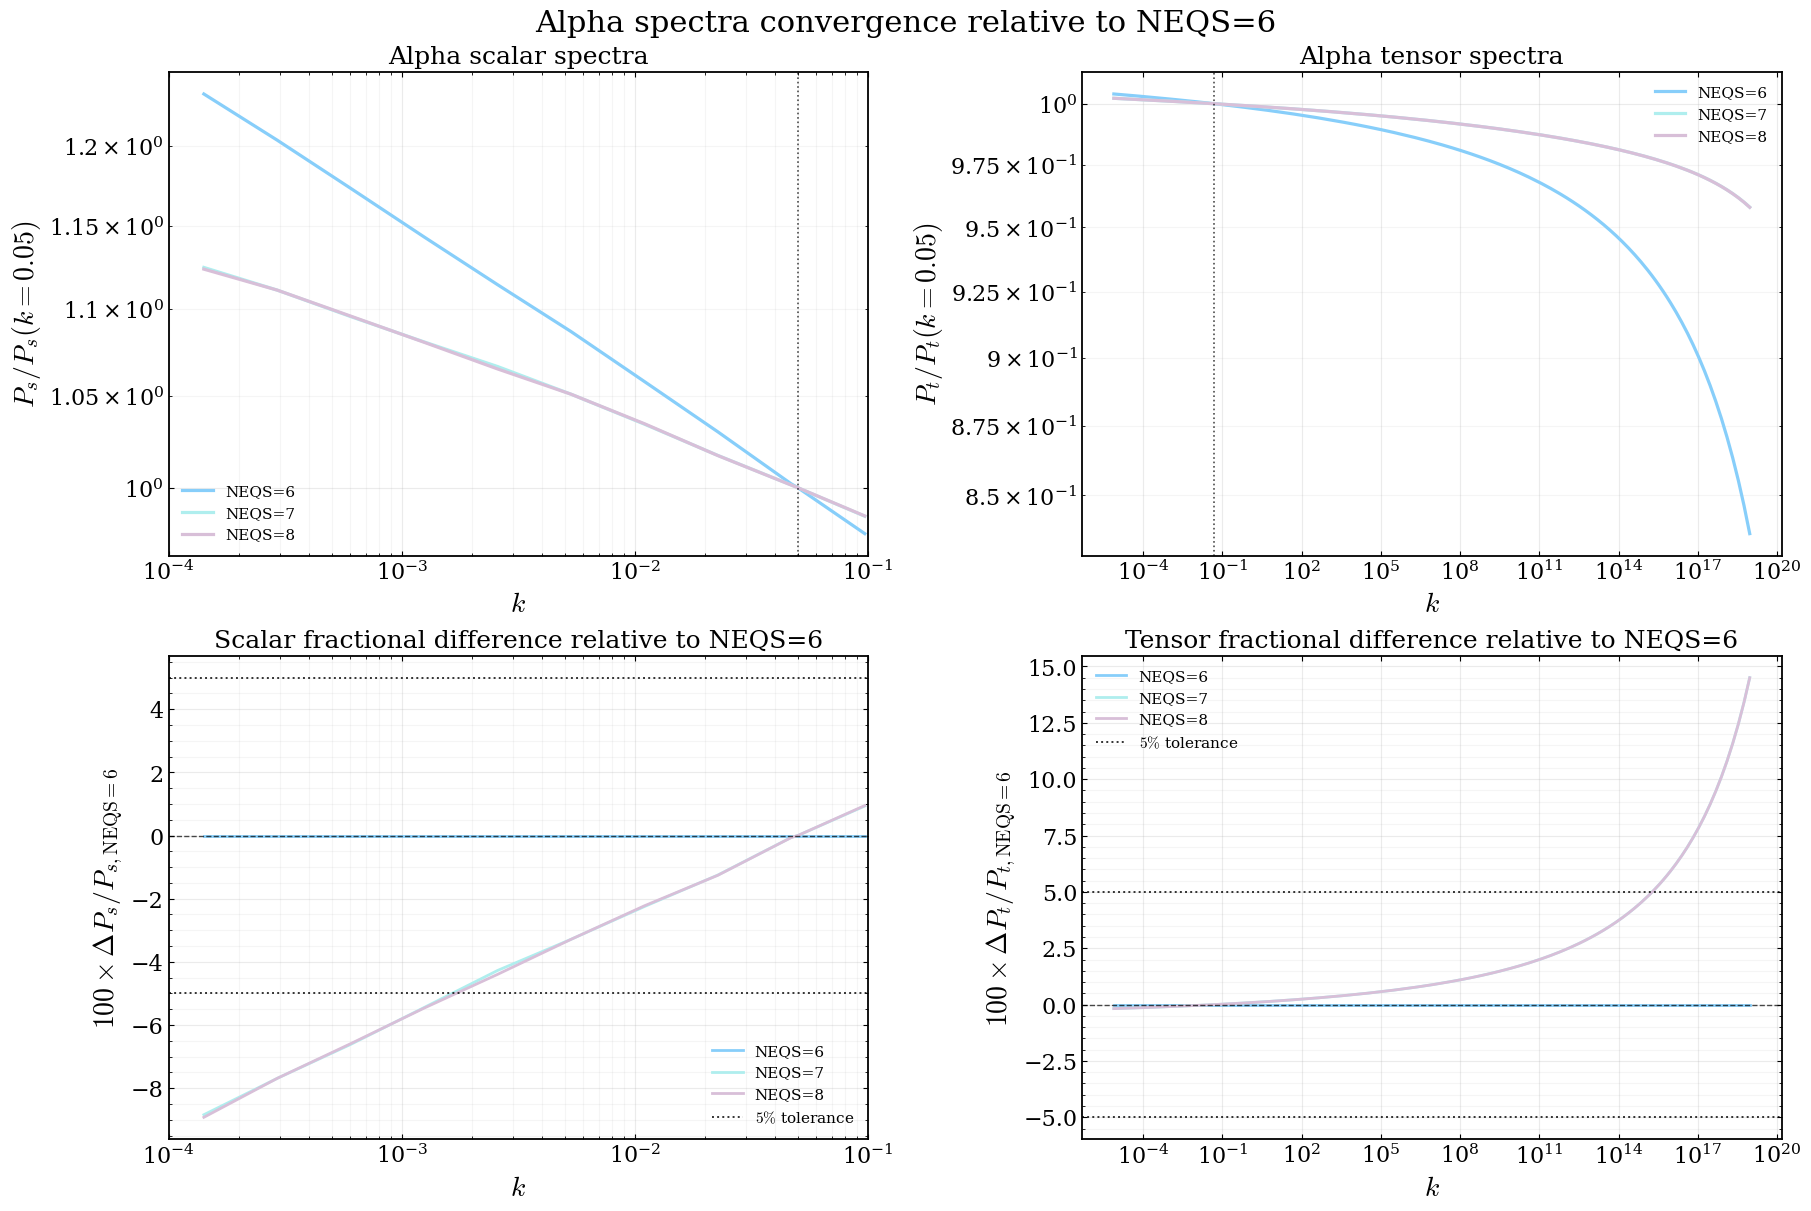


=== Base spectra convergence summary ===
 NEQS param_name  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    6       lam3          0.000000         0.000000          0.000000         0.000000
    7       lam4          3.694476         8.840771          2.520479        14.503705
    8       lam5          3.712957         8.922751          2.519730        14.499038

--- k-shift equivalence test ---

Reference NEQS=6: N_end=940.5694757504

NEQS=7
  N_end           = 961.1922664127
  reference N_end = 940.5694757504
  deltaN          = 20.6227906622
  exp(-deltaN)    = 1.1056961921e-09

NEQS=8
  N_end           = 961.1796239442
  reference N_end = 940.5694757504
  deltaN          = 20.6101481937
  exp(-deltaN)    = 1.1197636578e-09


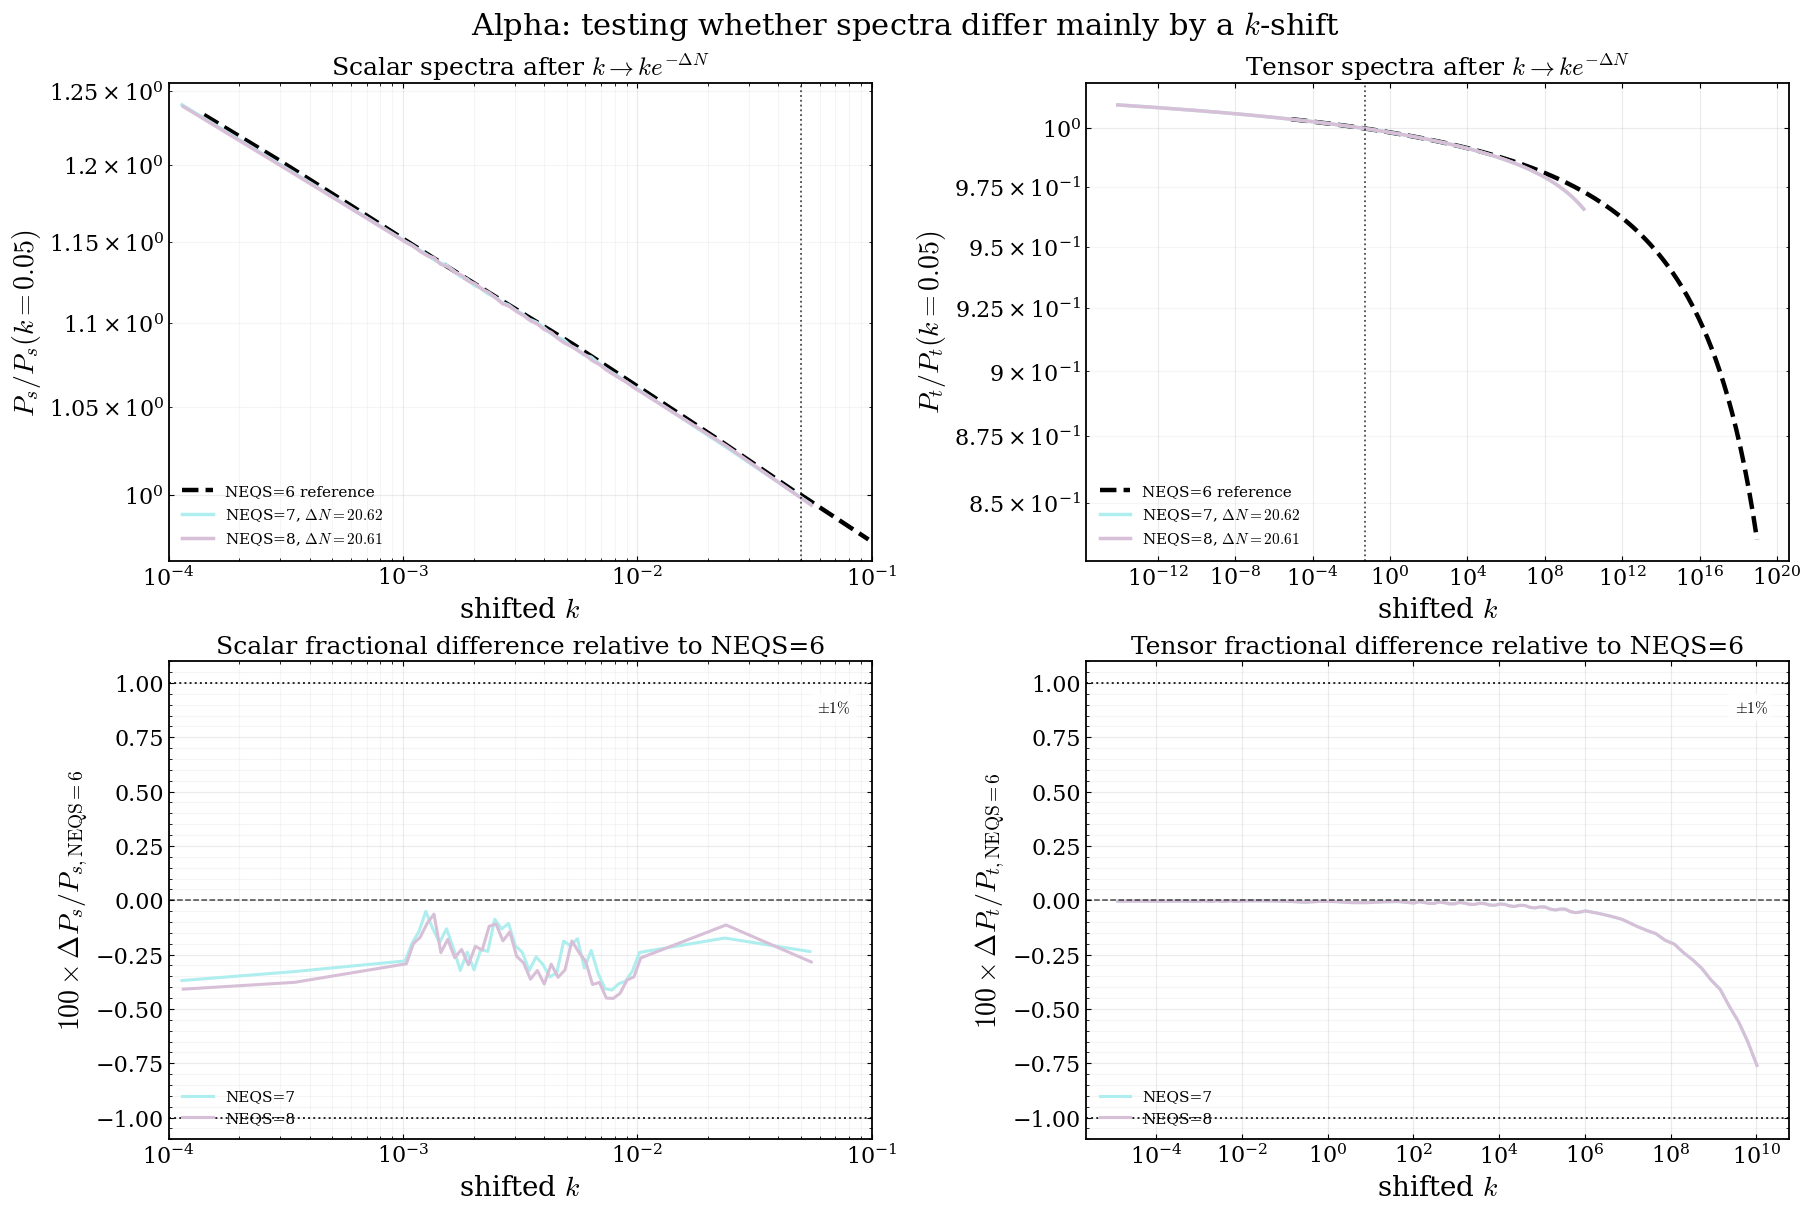


=== Shifted base spectra summary ===
 NEQS param_name  original_N_end  ref_N_end  deltaN_from_ref  k_shift_factor  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    7       lam4      961.192266 940.569476        20.622791    1.105696e-09          0.249615         0.413087          0.061604         0.758518
    8       lam5      961.179624 940.569476        20.610148    1.119764e-09          0.271909         0.451790          0.061977         0.760851

DONE: alpha


In [33]:
base_summary_alpha, results_alpha = run_model_convergence_suite(
    model_id="alpha",
    base_path_root=base_path_root,
    ref_NEQS=6,
    save_plots=True,
    show_plots=True,

    run_background=False,
    run_spectra=True,
    run_derivative=False,
    run_kshift=True,
    run_shifted_derivative=False,
)

## For Hilltop


RUNNING CONVERGENCE SUITE FOR: hilltop
NEQS=6
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs6_nonhiggs_hilltop/lam2_2.6624000000e-04_lam3_-2.2767400000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00
NEQS=7
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs7_nonhiggs_hilltop/lam2_2.6624000000e-04_lam3_-2.2767400000e-06_lam4_3.4831307982e-07_lam5_0.0000000000e+00
NEQS=8
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs8_nonhiggs_hilltop/lam2_2.6624000000e-04_lam3_-2.2767400000e-06_lam4_3.4831307982e-07_lam5_-3.4920800000e-10

Base summary:
 NEQS  original_N_end        r      n_s   alpha_s
    6      940.534935 0.005070 0.960252 -0.000575
    7      949.183447 0.003672 0.964723 -0.000471
    8      949.288775 0.003659 0.96

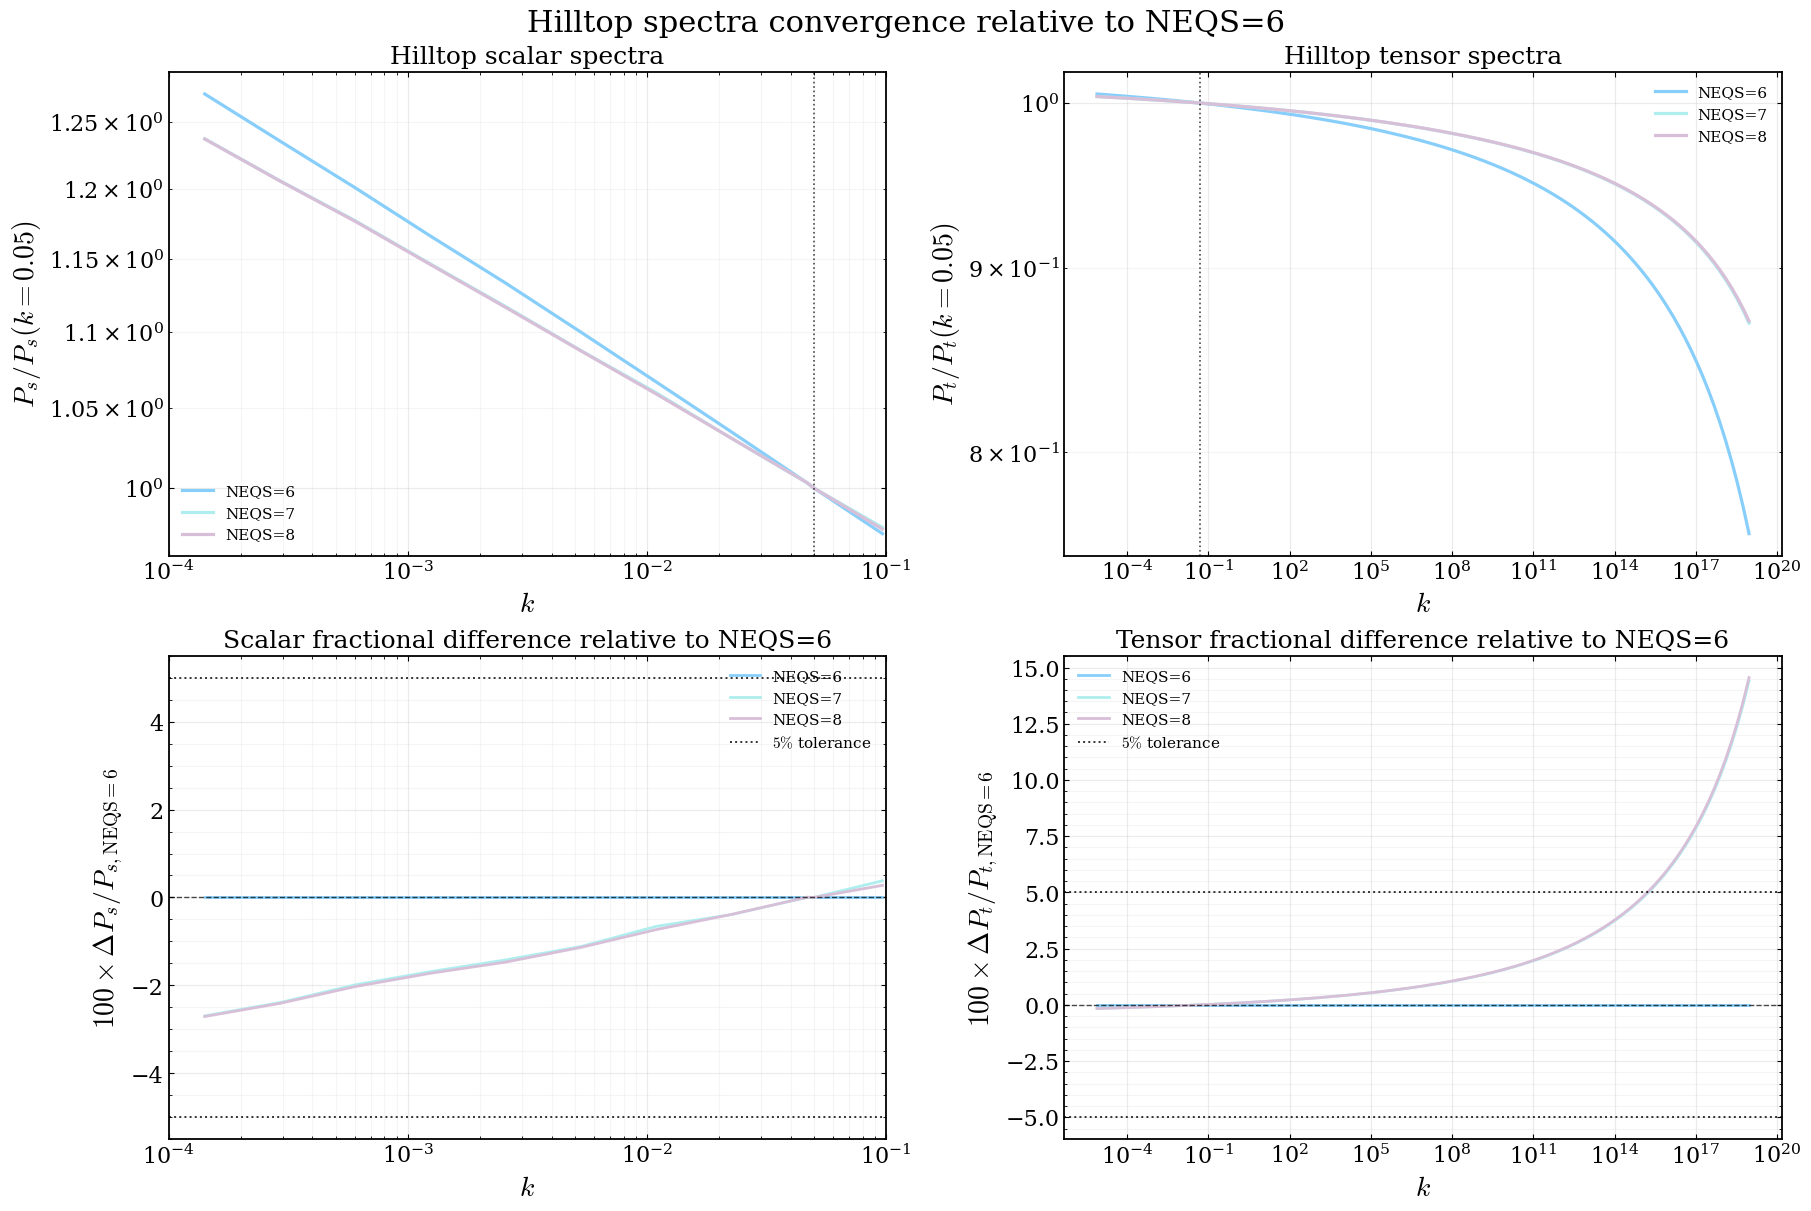


=== Base spectra convergence summary ===
 NEQS param_name  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    6       lam3          0.000000         0.000000          0.000000         0.000000
    7       lam4          1.156024         2.692910          2.503172        14.398477
    8       lam5          1.169182         2.707282          2.526617        14.549164

--- k-shift equivalence test ---

Reference NEQS=6: N_end=940.5349352463

NEQS=7
  N_end           = 949.1834473213
  reference N_end = 940.5349352463
  deltaN          = 8.6485120750
  exp(-deltaN)    = 1.7538761773e-04

NEQS=8
  N_end           = 949.2887746550
  reference N_end = 940.5349352463
  deltaN          = 8.7538394087
  exp(-deltaN)    = 1.5785409377e-04


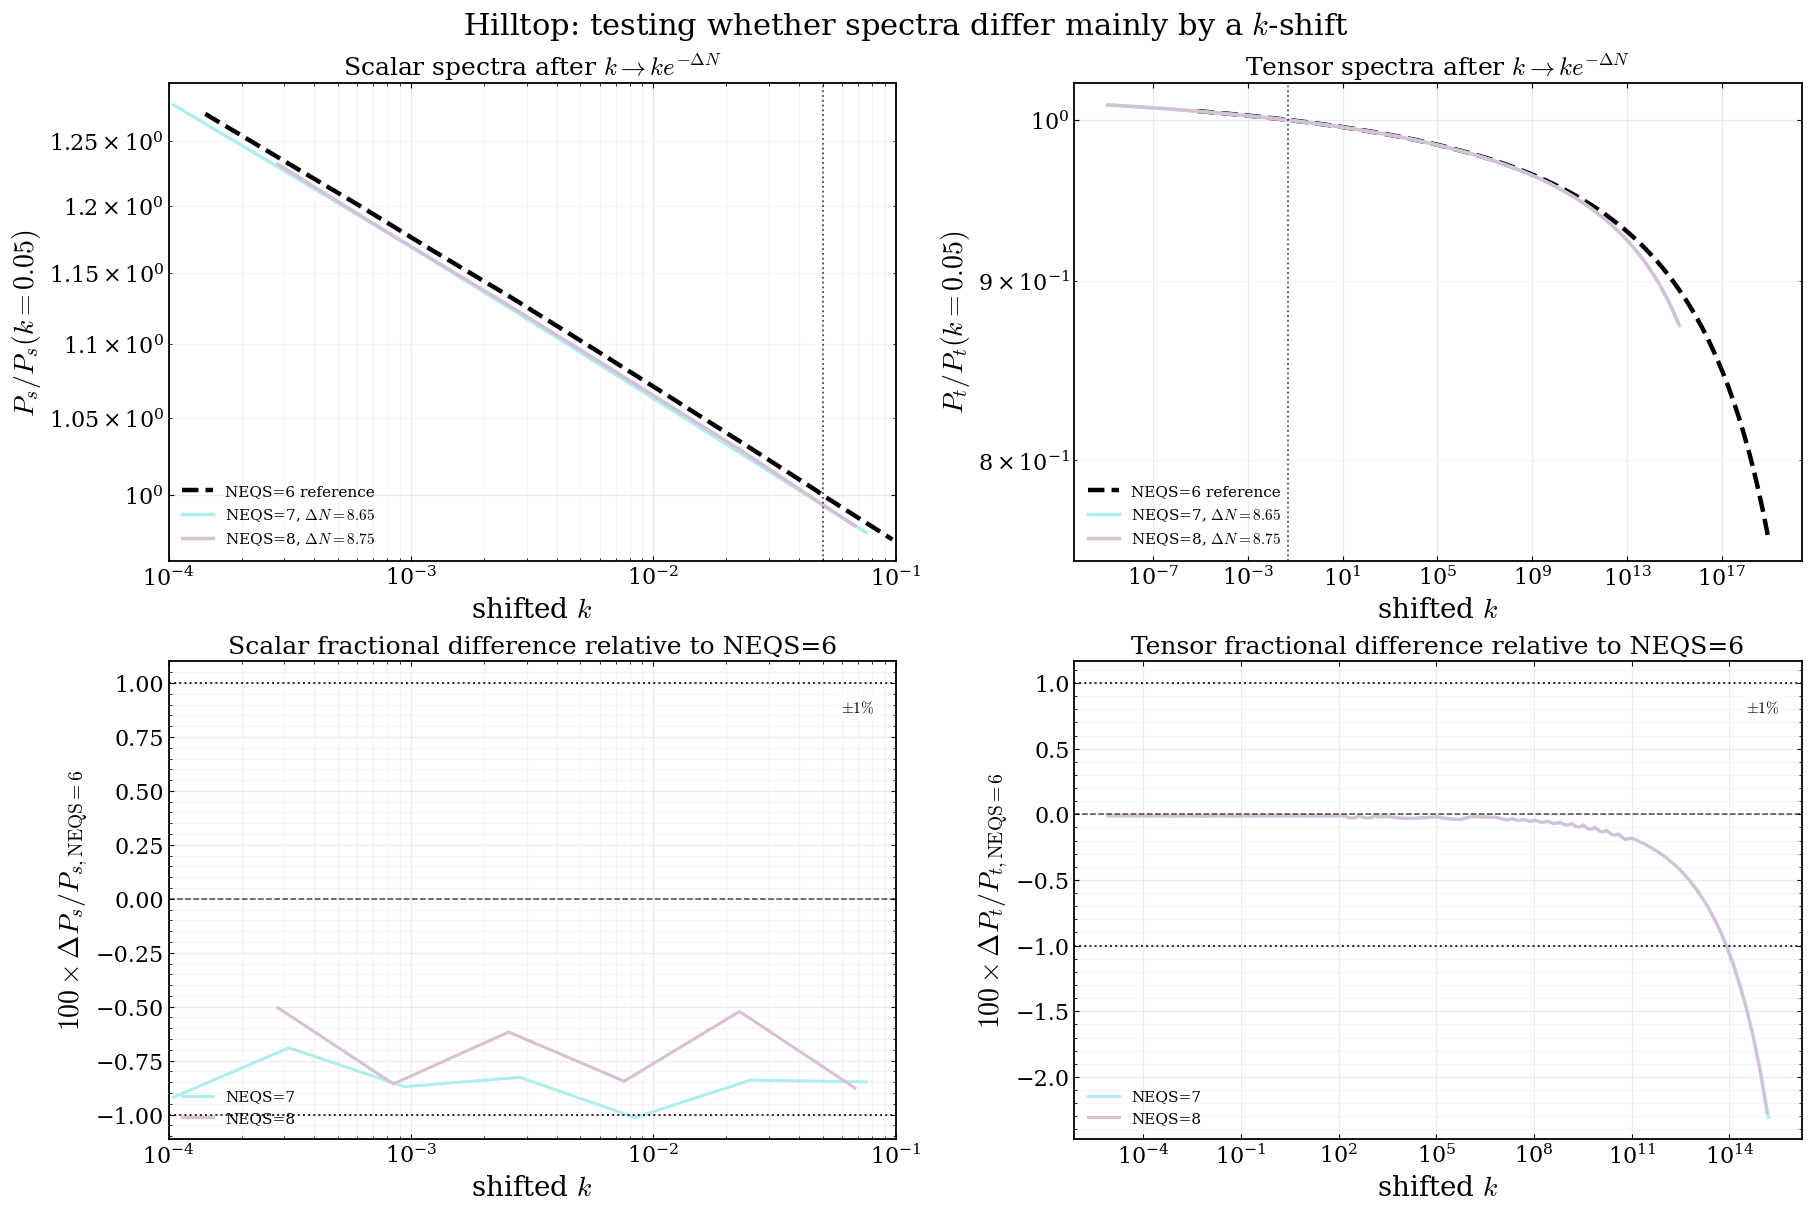


=== Shifted base spectra summary ===
 NEQS param_name  original_N_end  ref_N_end  deltaN_from_ref  k_shift_factor  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    7       lam4      949.183447 940.534935         8.648512        0.000175          0.858627         1.013791          0.186441         2.309209
    8       lam5      949.288775 940.534935         8.753839        0.000158          0.704165         0.876705          0.183660         2.274955

DONE: hilltop


In [34]:
base_summary_hilltop, results_hilltop = run_model_convergence_suite(
    model_id="hilltop",
    base_path_root=base_path_root,
    ref_NEQS=6,
    save_plots=True,
    show_plots=True,

    run_background=False,
    run_spectra=True,
    run_derivative=False,
    run_kshift=True,
    run_shifted_derivative=False,
)

## For Quadratic (Deformed)


RUNNING CONVERGENCE SUITE FOR: quaddeformed
NEQS=6
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs6_nonhiggs_quaddeformed/lam2_-1.9005400000e-04_lam3_-6.2283400000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00
NEQS=7
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs7_nonhiggs_quaddeformed/lam2_-1.9005400000e-04_lam3_-6.2283400000e-06_lam4_-9.2247700000e-08_lam5_0.0000000000e+00
NEQS=8
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs8_nonhiggs_quaddeformed/lam2_-1.9005400000e-04_lam3_-6.2283400000e-06_lam4_-9.2247700000e-08_lam5_-1.8547900000e-09

Base summary:
 NEQS  original_N_end        r      n_s   alpha_s
    6      947.688277 0.101057 0.962712 -0.000285
    7      944.362370 0.109571 0.961670 -0.000343
    8     

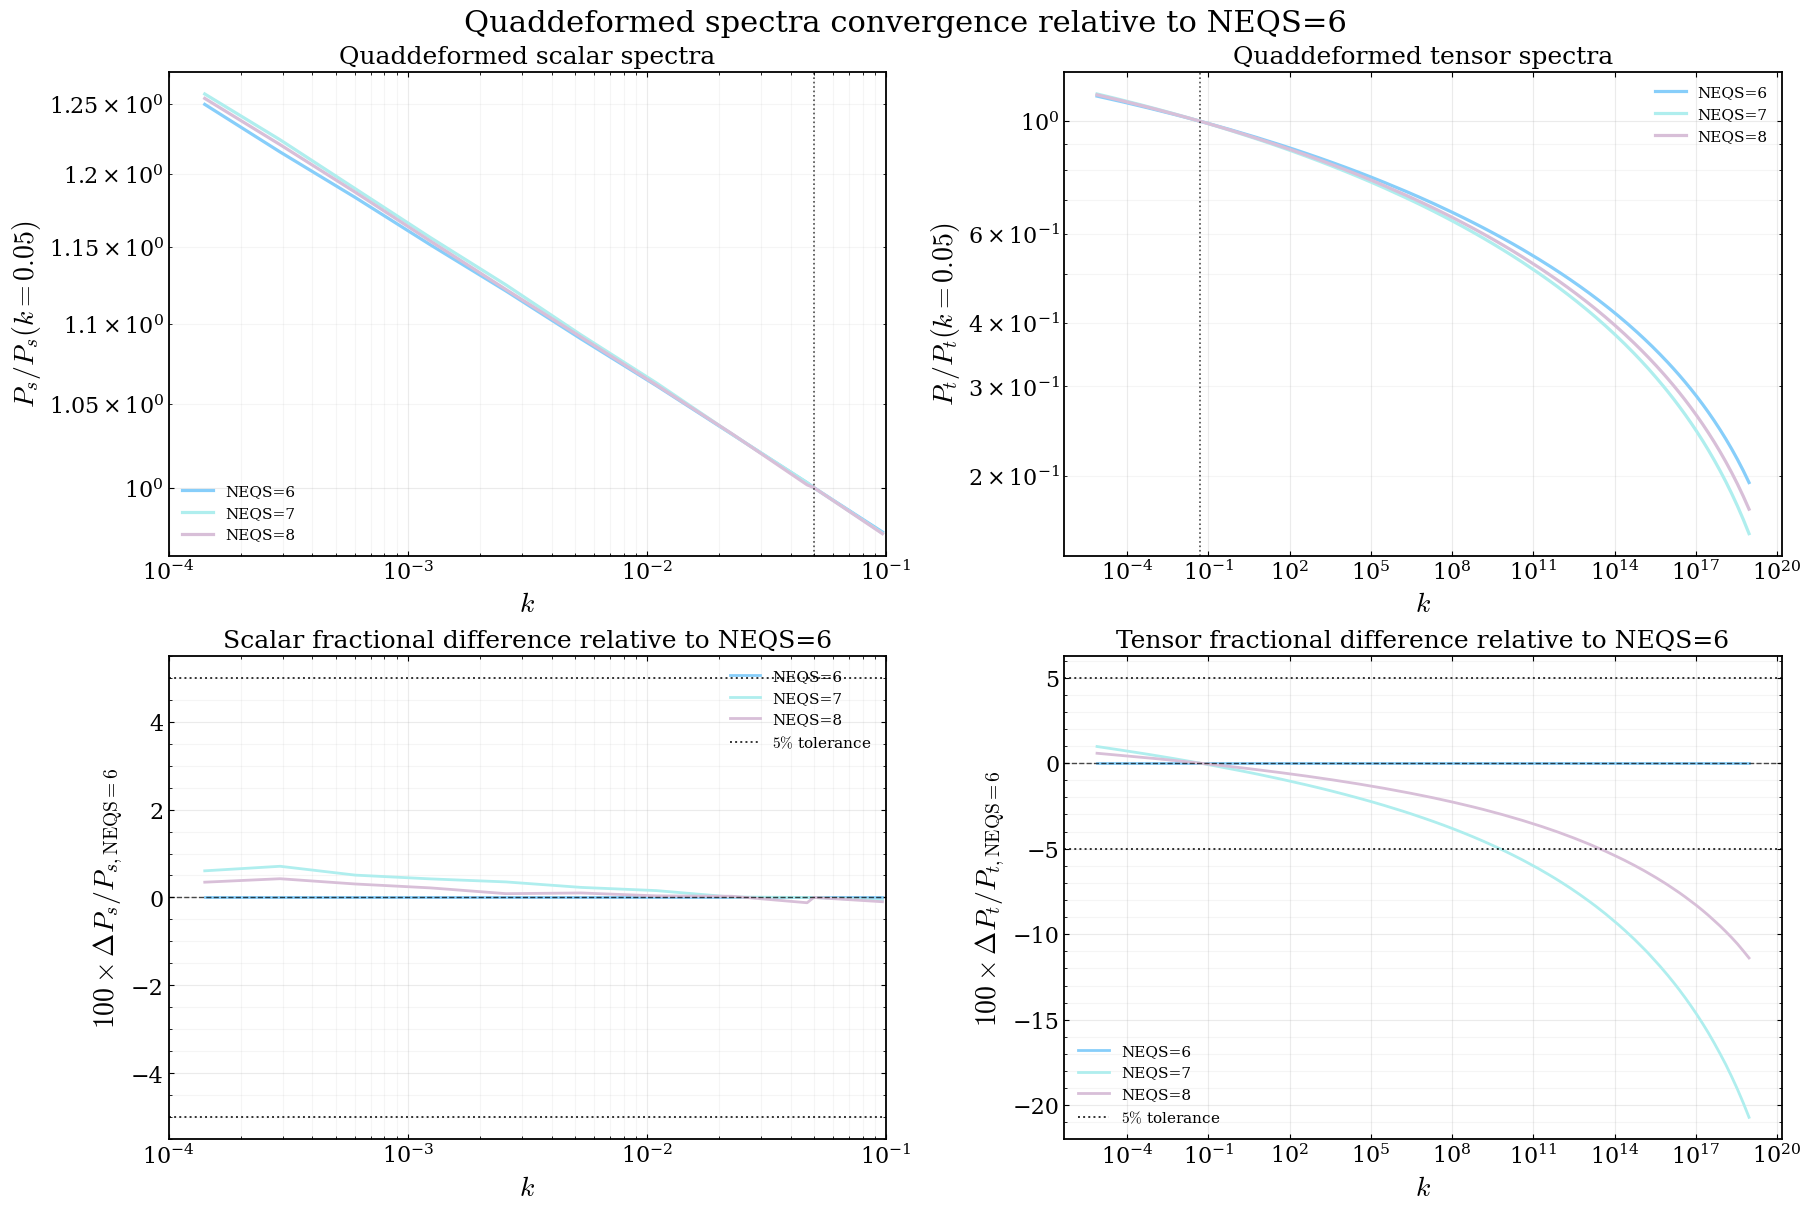


=== Base spectra convergence summary ===
 NEQS param_name  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    6       lam3           0.00000         0.000000          0.000000         0.000000
    7       lam4           0.27860         0.709593          5.885612        20.704881
    8       lam5           0.16083         0.426465          3.409793        11.388486

--- k-shift equivalence test ---

Reference NEQS=6: N_end=947.6882765057

NEQS=7
  N_end           = 944.3623704228
  reference N_end = 947.6882765057
  deltaN          = -3.3259060828
  exp(-deltaN)    = 2.7824198253e+01

NEQS=8
  N_end           = 945.6711373719
  reference N_end = 947.6882765057
  deltaN          = -2.0171391338
  exp(-deltaN)    = 7.5167896140e+00


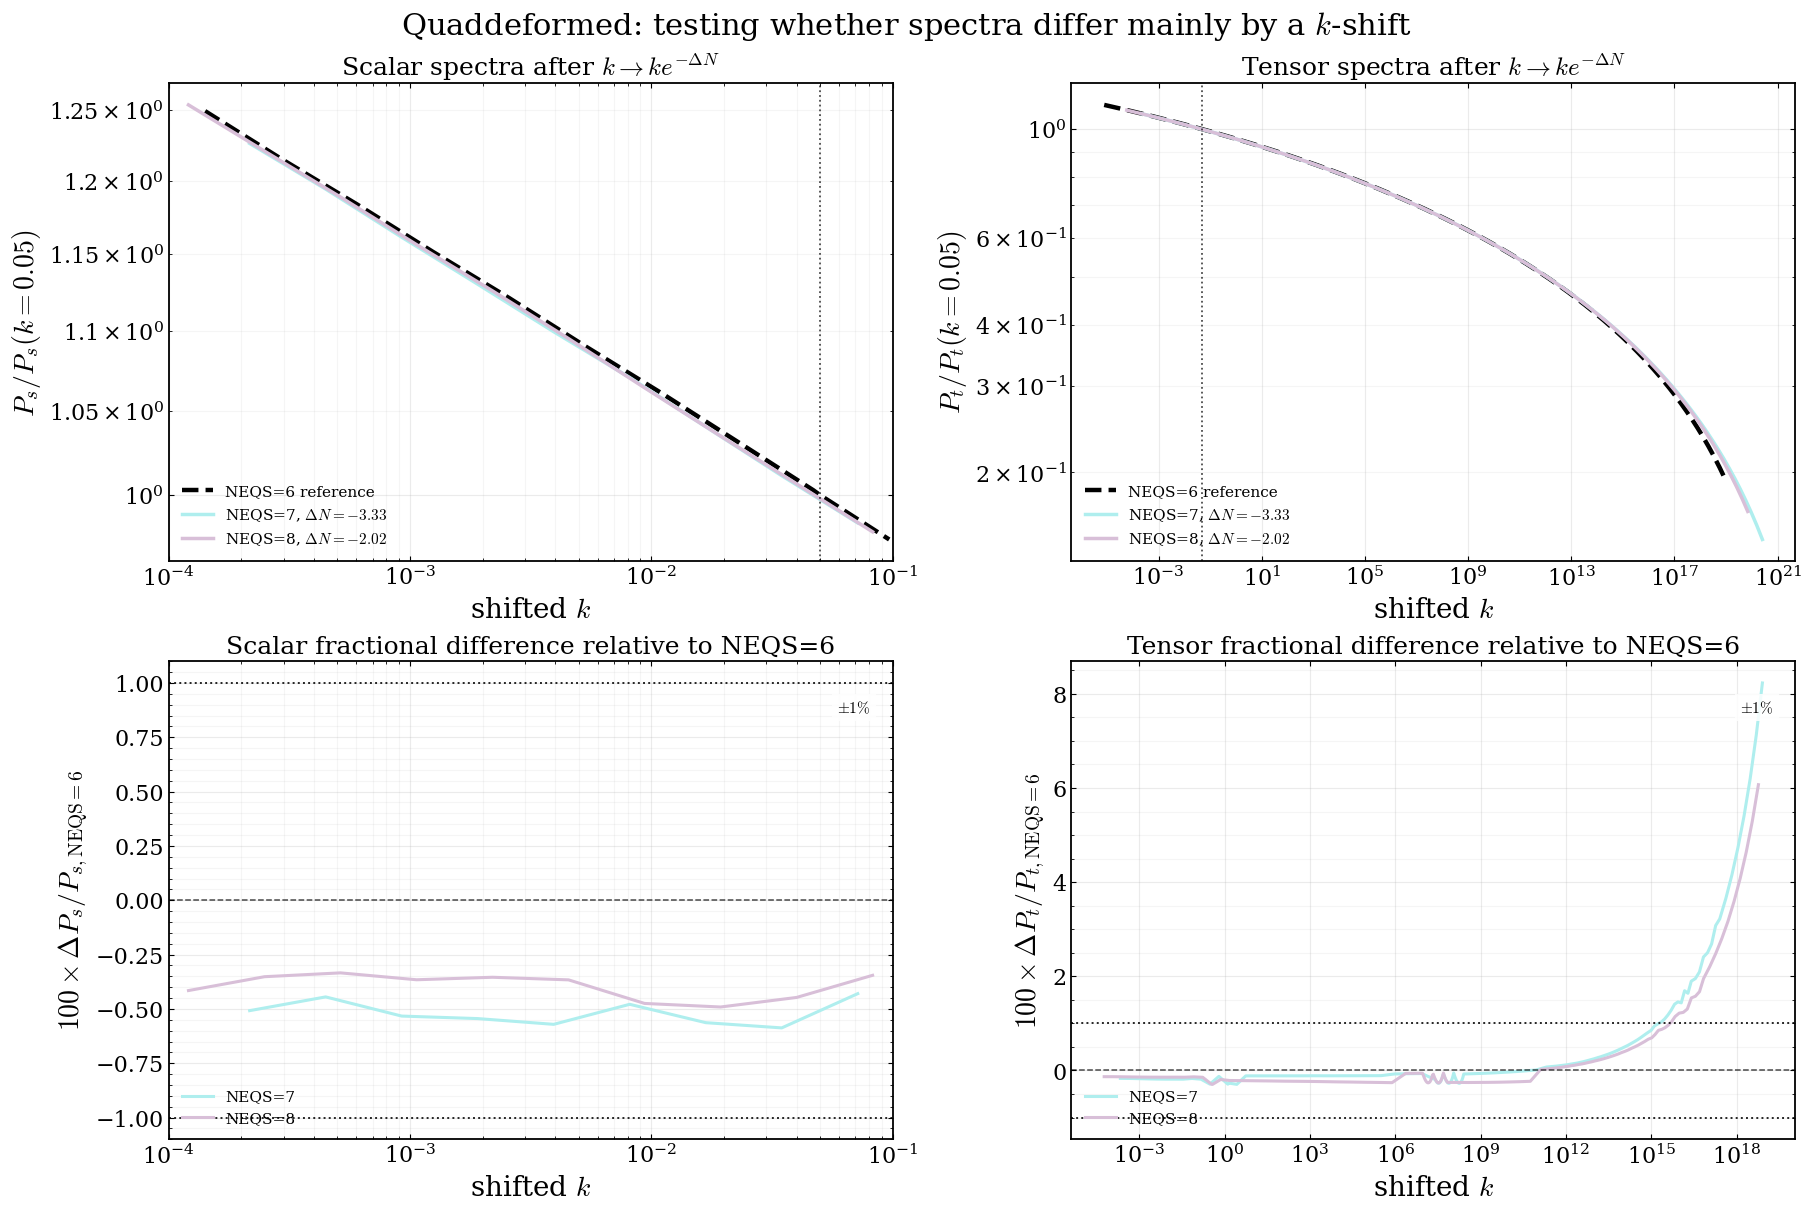


=== Shifted base spectra summary ===
 NEQS param_name  original_N_end  ref_N_end  deltaN_from_ref  k_shift_factor  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    7       lam4      944.362370 947.688277        -3.325906       27.824198          0.517835         0.587371          0.778512         8.229942
    8       lam5      945.671137 947.688277        -2.017139        7.516790          0.394657         0.491206          0.589753         6.069602

DONE: quaddeformed


In [35]:
base_summary_quaddeformed, results_quaddeformed = run_model_convergence_suite(
    model_id="quaddeformed",
    base_path_root=base_path_root,
    ref_NEQS=6,
    save_plots=True,
    show_plots=True,

    run_background=False,
    run_spectra=True,
    run_derivative=False,
    run_kshift=True,
    run_shifted_derivative=False,
)

## For Natural

In [ ]:
base_summary_natural, results_natural = run_model_convergence_suite(
    model_id="natural",
    base_path_root=base_path_root,
    ref_NEQS=6,
    save_plots=True,
    show_plots=True,

    run_background=False,
    run_spectra=True,
    run_derivative=False,
    run_kshift=True,
    run_shifted_derivative=False,
)

## For Higgs


RUNNING CONVERGENCE SUITE FOR: higgs
NEQS=6
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs6_nonhiggs_higgs/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00
NEQS=7
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs7_nonhiggs_higgs/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_6.8706500000e-08_lam5_0.0000000000e+00
NEQS=8
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/nonhiggs_potential_tests/neqs8_nonhiggs_higgs/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_6.8706500000e-08_lam5_-8.9246100000e-09

Base summary:
 NEQS  original_N_end        r      n_s   alpha_s
    6      939.163572 0.003454 0.965678 -0.000596
    7      941.837071 0.003158 0.967201 -0.000545
    8      946.349733 0.002737 0.969485 -0.

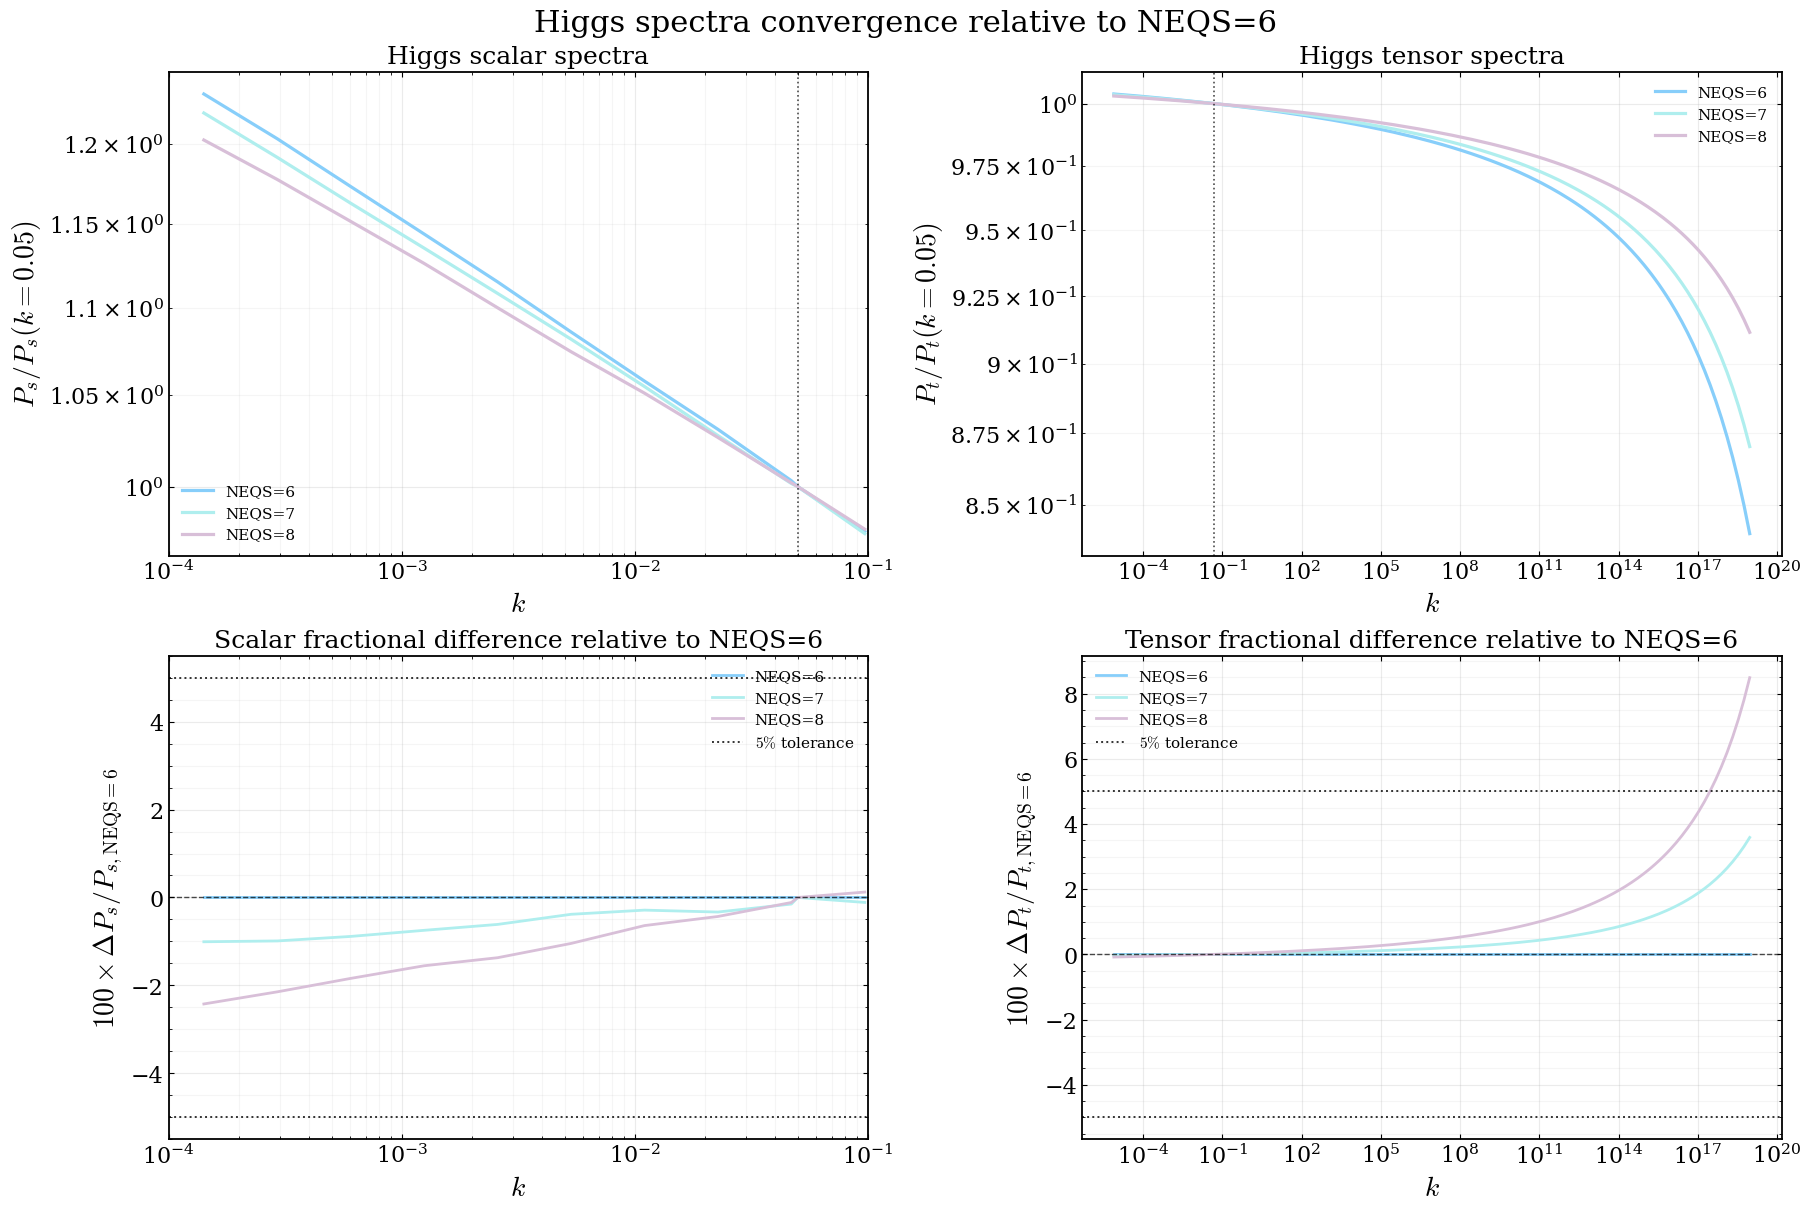


=== Base spectra convergence summary ===
 NEQS param_name  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    6       lam3          0.000000         0.000000          0.000000         0.000000
    7       lam4          0.500590         1.007252          0.581903         3.588191
    8       lam5          1.062508         2.422227          1.352162         8.492546

--- k-shift equivalence test ---

Reference NEQS=6: N_end=939.1635722724

NEQS=7
  N_end           = 941.8370708048
  reference N_end = 939.1635722724
  deltaN          = 2.6734985323
  exp(-deltaN)    = 6.9010367482e-02

NEQS=8
  N_end           = 946.3497329093
  reference N_end = 939.1635722724
  deltaN          = 7.1861606368
  exp(-deltaN)    = 7.5698990752e-04


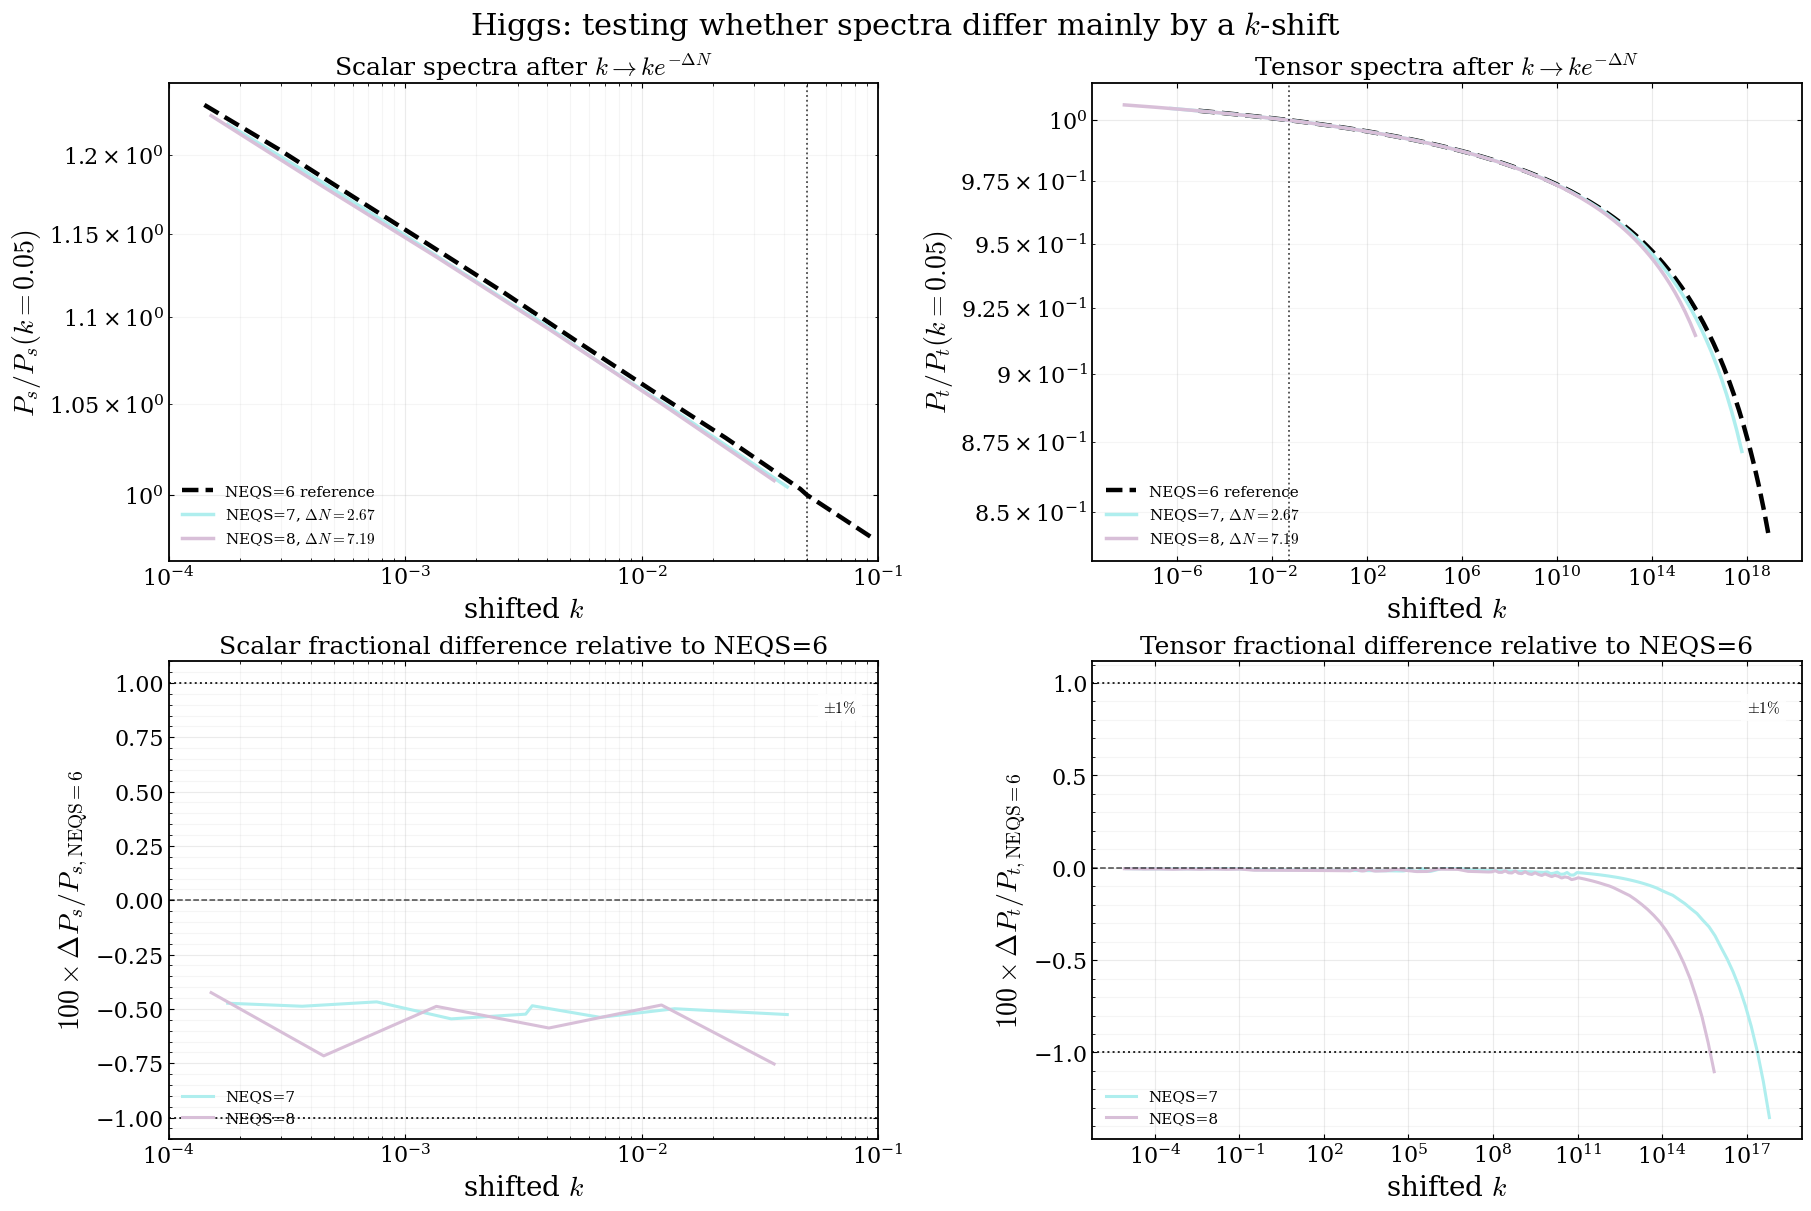


=== Shifted base spectra summary ===
 NEQS param_name  original_N_end  ref_N_end  deltaN_from_ref  k_shift_factor  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    7       lam4      941.837071 939.163572         2.673499        0.069010          0.505379         0.545812          0.098455         1.352413
    8       lam5      946.349733 939.163572         7.186161        0.000757          0.575461         0.753419          0.084718         1.104184

DONE: higgs


In [32]:
base_summary_higgs, results_higgs = run_model_convergence_suite(
    model_id="higgs",
    base_path_root=base_path_root,
    ref_NEQS=6,
    save_plots=True,
    show_plots=True,

    run_background=False,
    run_spectra=True,
    run_derivative=False,
    run_kshift=True,
    run_shifted_derivative=False,
)